# **Predictive Maintenance**

## **Objective**

The goal for this notebook is to contruct a classification model that is able to predict whether or not a given machine will benefit from predictive maintenance. In other words, we're predicting whether or not a given machine has/will fail.

## **Loading Dataset**

In [1]:
# Importing the required libraries
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
# Library for data manipulation and analysis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("predictive_maintenance.csv")

In [3]:
df.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


## **Data Summary and Preprocessing**

**Columns:**
- **UID:** unique identifier ranging from 1 to 10000
- **productID:** consisting of a letter L, M, or H for low (50% of all products), medium (30%), and high (20%) as product quality variants and a variant-specific serial number
- **air temperature [K]:** generated using a random walk process later normalized to a standard deviation of 2 K around 300 K
- **process temperature [K]:** generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.
- **rotational speed [rpm]:** calculated from powepower of 2860 W, overlaid with a normally distributed noise
- **torque [Nm]:** torque values are normally distributed around 40 Nm with an Ïƒ = 10 Nm and no negative values.
- **tool wear [min]:** The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process. and a
- **'machine failure'** label that indicates, whether the machine has failed in this particular data point for any of the following failure modes are true.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


- There is a roughly even mix of float64, int64, and object data types among the columns.

**Objects:**
- Product ID
- Type
- Failure Type

**Float:**
- Air temperature [K]
- Process temperature [K]
- Torque [Nm]

**Int:**
- UDI
- Rotational speed [rpm]
- Tool wear [min]
- Target (boolean)

Between these 10 columns, there are two potential targets: 'Target' and 'Failure Type'. 'Target' is boolean, and denotes whether or not the machine failed, while 'Failure Type' denotes the specific type of failure that occurred, if any.

Our target will be 'Target', so we can get rid of 'Failure Type' now, to prevent data leakage.

In [5]:
df = df.drop(['Failure Type'], axis=1)

While we're at it, we can also get rid of 'UDI', and 'Product ID', since these both contain solely unique values, and will not provide any use in this classification objective. 

In [6]:
df = df.drop(['UDI', 'Product ID'], axis=1)

#### Duplicates

In [7]:
# Checking for duplicate rows
df.duplicated().sum()

0

#### Missing Values

Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
dtype: int64

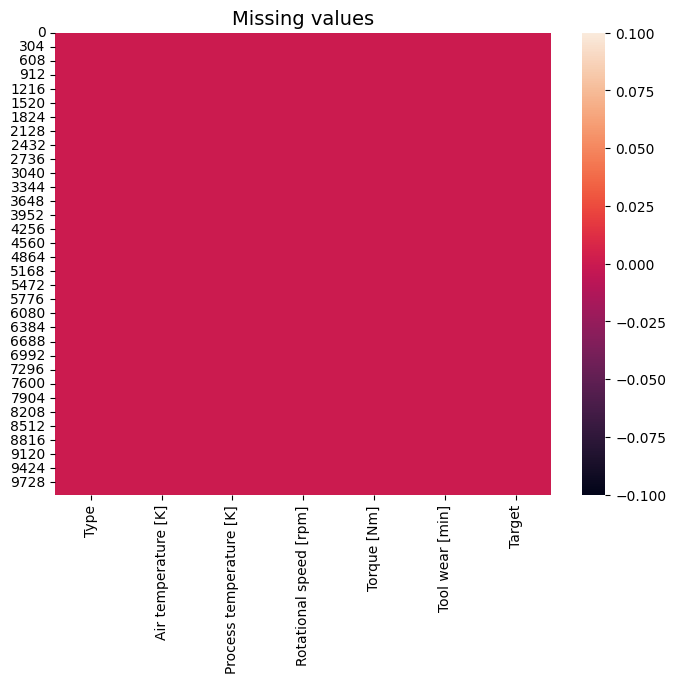

In [8]:
# Number of missing values in each column
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull())
plt.title("Missing values", fontsize=14)
df.isna().sum()

Thankfully, there are no duplicates or missing values in the dataset, so there is much less work to be done.

In [9]:
df.head(5)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


#### Outliers

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Target,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0


It does appear as though there could be some outliers, especially when looking at the 'Tool wear' column. However, since there are not many features available to us, and the dataset isn't particularly large, I am hesitant about removing any outliers. So, because of this, we will move on as-is.

## **Exploratory Data Analysis**

In [11]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    data[feature].describe()
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [12]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [13]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [14]:
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

##### **Type**

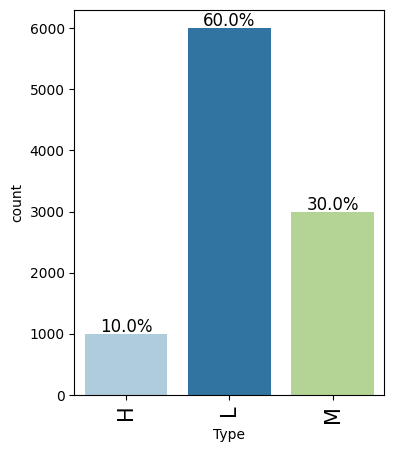

In [15]:
labeled_barplot(df, 'Type', perc=True)

**Observations:**
- Most of the entries are of type "L".
- Second most common type is "M", with "H" being the least prevalent by a lot.

##### **Air temperature**

In [16]:
df['Air temperature [K]'].describe()

count    10000.000000
mean       300.004930
std          2.000259
min        295.300000
25%        298.300000
50%        300.100000
75%        301.500000
max        304.500000
Name: Air temperature [K], dtype: float64

In [17]:
df['Air temperature [K]'].mode()

0    300.7
Name: Air temperature [K], dtype: float64

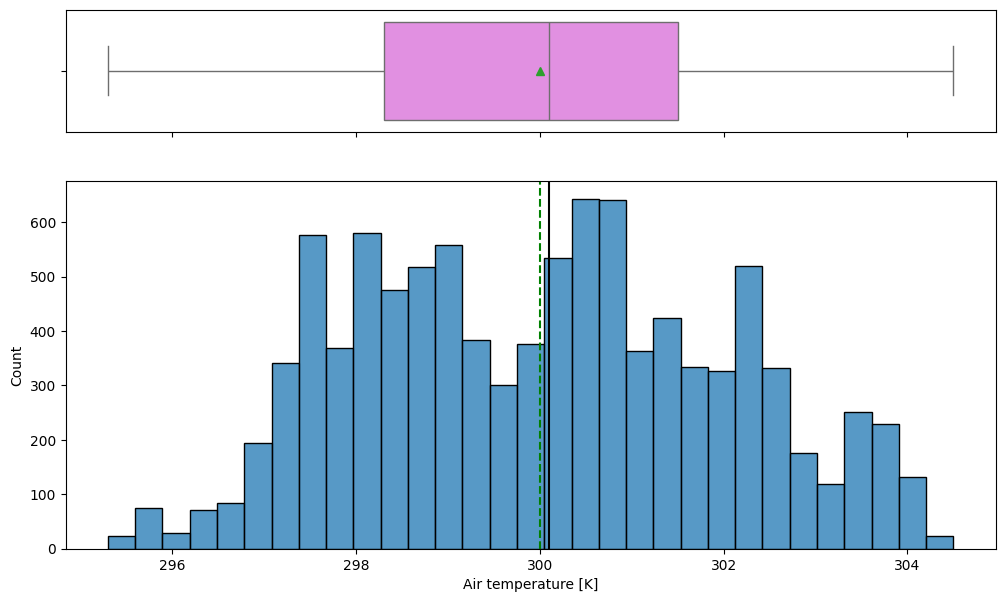

In [18]:
histogram_boxplot(df, 'Air temperature [K]');

**Observations:**
- Distribution is fairly normal, with two clusters being on either side of the median.
- Mean, Median, and Mode are all about 300.

##### **Process temperature**

In [19]:
df['Process temperature [K]'].describe()

count    10000.000000
mean       310.005560
std          1.483734
min        305.700000
25%        308.800000
50%        310.100000
75%        311.100000
max        313.800000
Name: Process temperature [K], dtype: float64

In [20]:
df['Process temperature [K]'].mode()

0    310.6
Name: Process temperature [K], dtype: float64

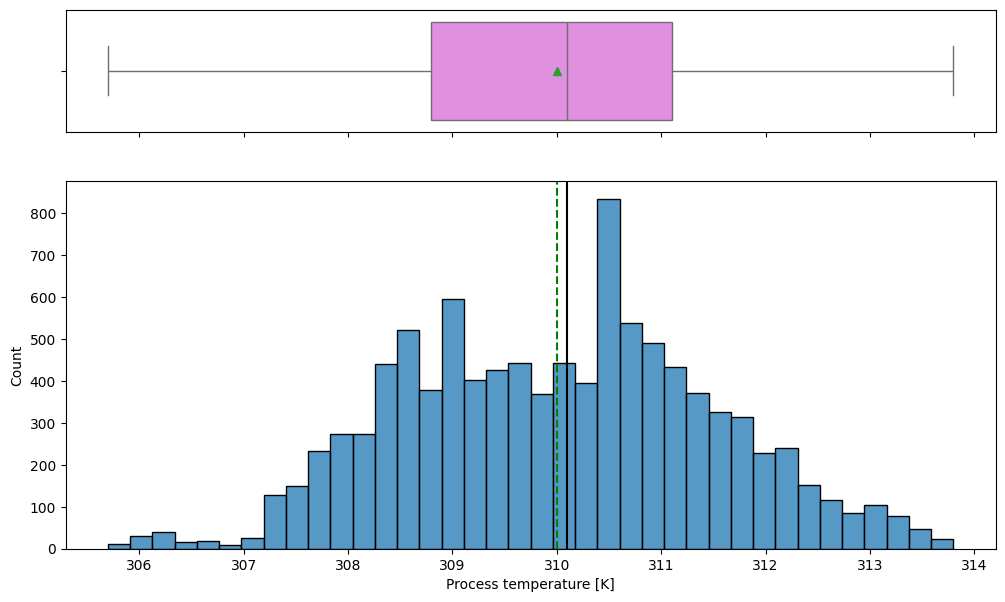

In [21]:
histogram_boxplot(df, 'Process temperature [K]');

**Observations:**
- Roughly normal distribution, more-so than Air temperature.
- Mean, median, and mode are all about 310.

##### **Rotational speed**

In [22]:
df['Rotational speed [rpm]'].describe()

count    10000.000000
mean      1538.776100
std        179.284096
min       1168.000000
25%       1423.000000
50%       1503.000000
75%       1612.000000
max       2886.000000
Name: Rotational speed [rpm], dtype: float64

In [23]:
df['Rotational speed [rpm]'].mode()

0    1452
Name: Rotational speed [rpm], dtype: int64

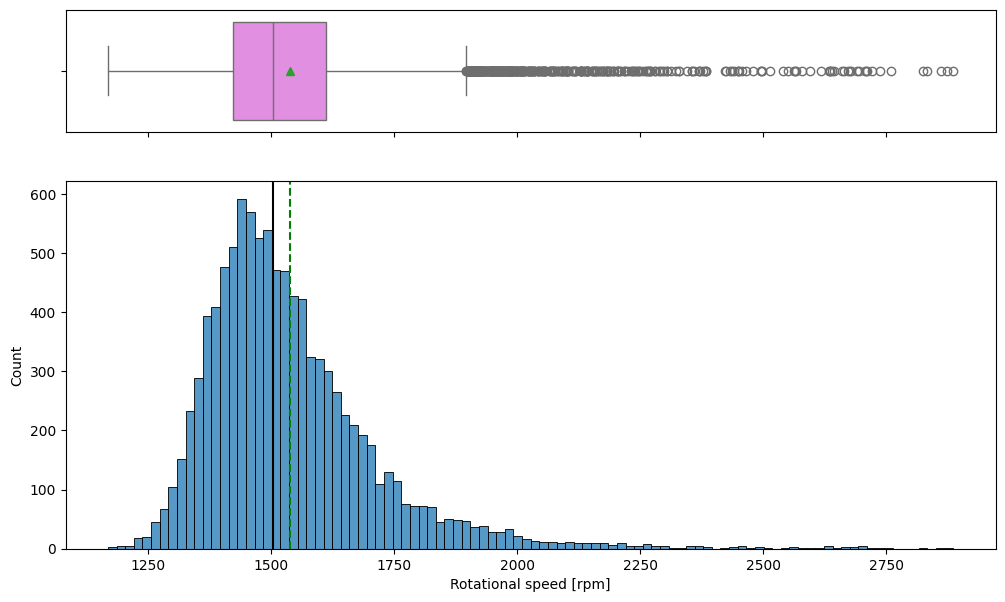

In [24]:
histogram_boxplot(df, 'Rotational speed [rpm]');

**Observations:**
- Distribution is heavily skewed right.
- Vast majority of data is clustered normally to the left of the median.
- Mean: 1549, Median: 1503, Mode: 1452

##### **Torque**

In [25]:
df['Torque [Nm]'].describe()

count    10000.000000
mean        39.986910
std          9.968934
min          3.800000
25%         33.200000
50%         40.100000
75%         46.800000
max         76.600000
Name: Torque [Nm], dtype: float64

In [26]:
df['Torque [Nm]'].mode()

0    40.2
Name: Torque [Nm], dtype: float64

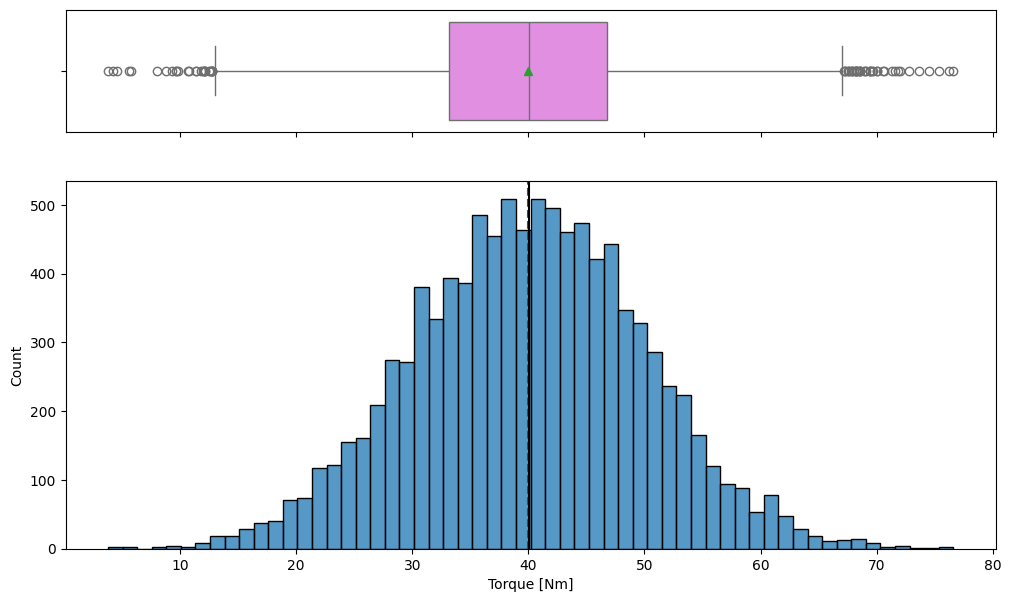

In [27]:
histogram_boxplot(df, 'Torque [Nm]');

**Observations:**
- Distribution is mostly normal.
- Mean, Median, and Mode are all about 40.

##### **Tool wear**

In [28]:
df['Tool wear [min]'].describe()

count    10000.000000
mean       107.951000
std         63.654147
min          0.000000
25%         53.000000
50%        108.000000
75%        162.000000
max        253.000000
Name: Tool wear [min], dtype: float64

In [29]:
df['Tool wear [min]'].mode()

0    0
Name: Tool wear [min], dtype: int64

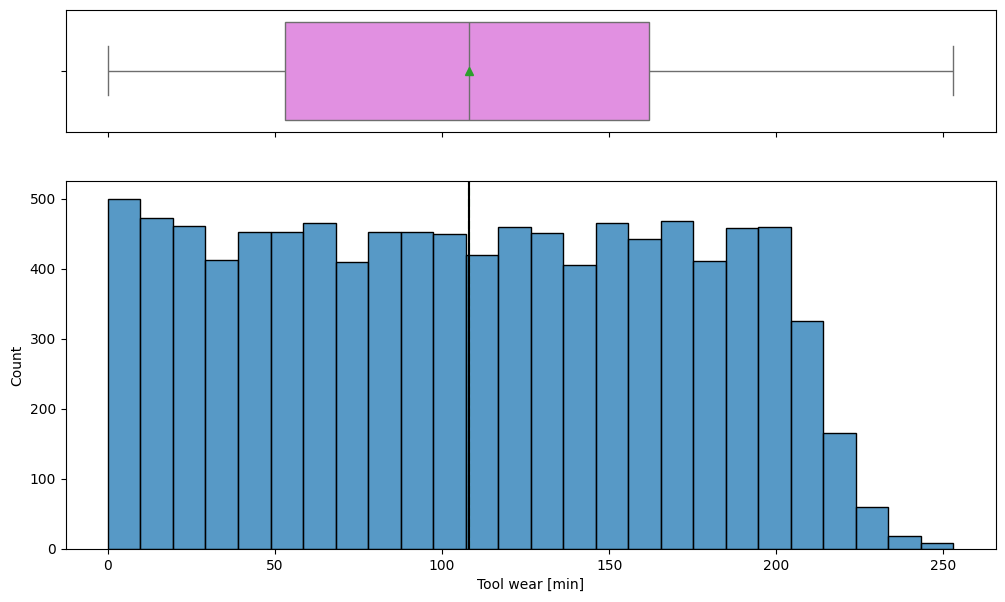

In [30]:
histogram_boxplot(df, 'Tool wear [min]');

**Observations:**
- Distribution is flat across the board, until about 200, then falls off heavily.
- Mean: 107, Median: 108, Mode: 0

##### **Target**

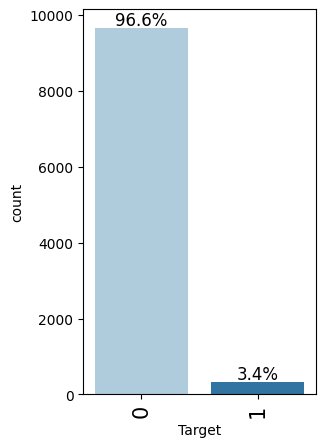

In [31]:
labeled_barplot(df, 'Target', perc=True)

**Observation:**
- The vast majority of the entries are negatives, by an extreme margin.
- Will likely require some oversampling.

### Muiltivariate Analysis

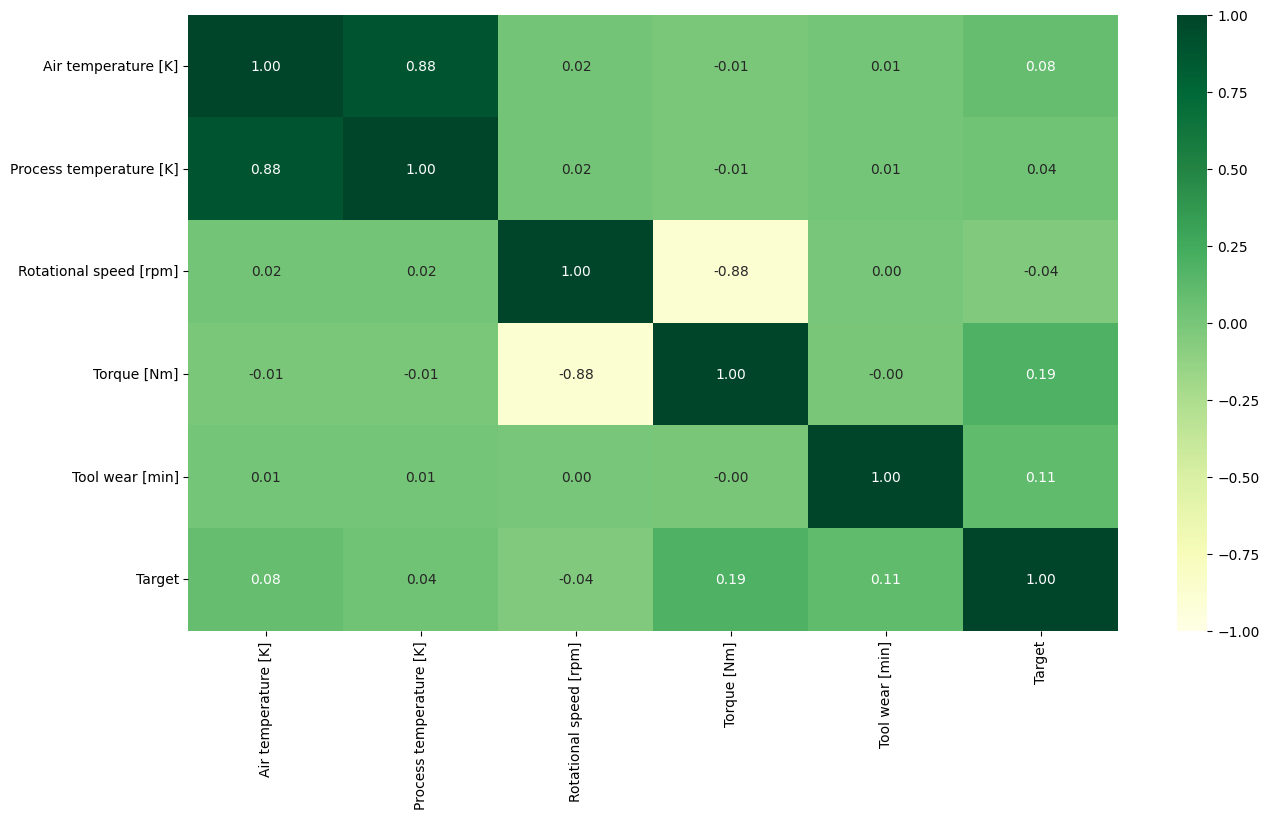

In [32]:
# Correlation heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="YlGn")
plt.show()

**Observations:**
- No features have a significant correlation to the target.
- Highest target correlation (0.19) with Torque.
- Highest overall correlation (0.88) between Air temperature and Process temperature.
- Lowest overall correlation (-0.88) between Rotational speed and Torque.

##### **target x Type**

Target     0    1    All
Type                    
All     9661  339  10000
L       5765  235   6000
M       2914   83   2997
H        982   21   1003
------------------------------------------------------------------------------------------------------------------------


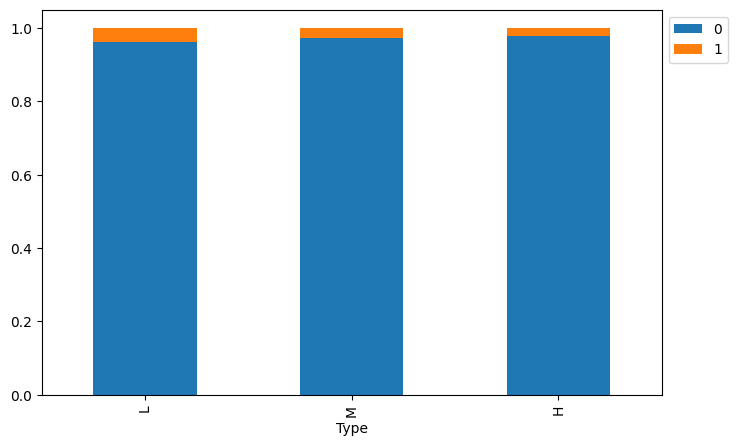

In [33]:
stacked_barplot(df, 'Type', 'Target')

**Observation(s):**
- Slight difference in L x Type, but extremely minute.

##### **target x Air temperature**

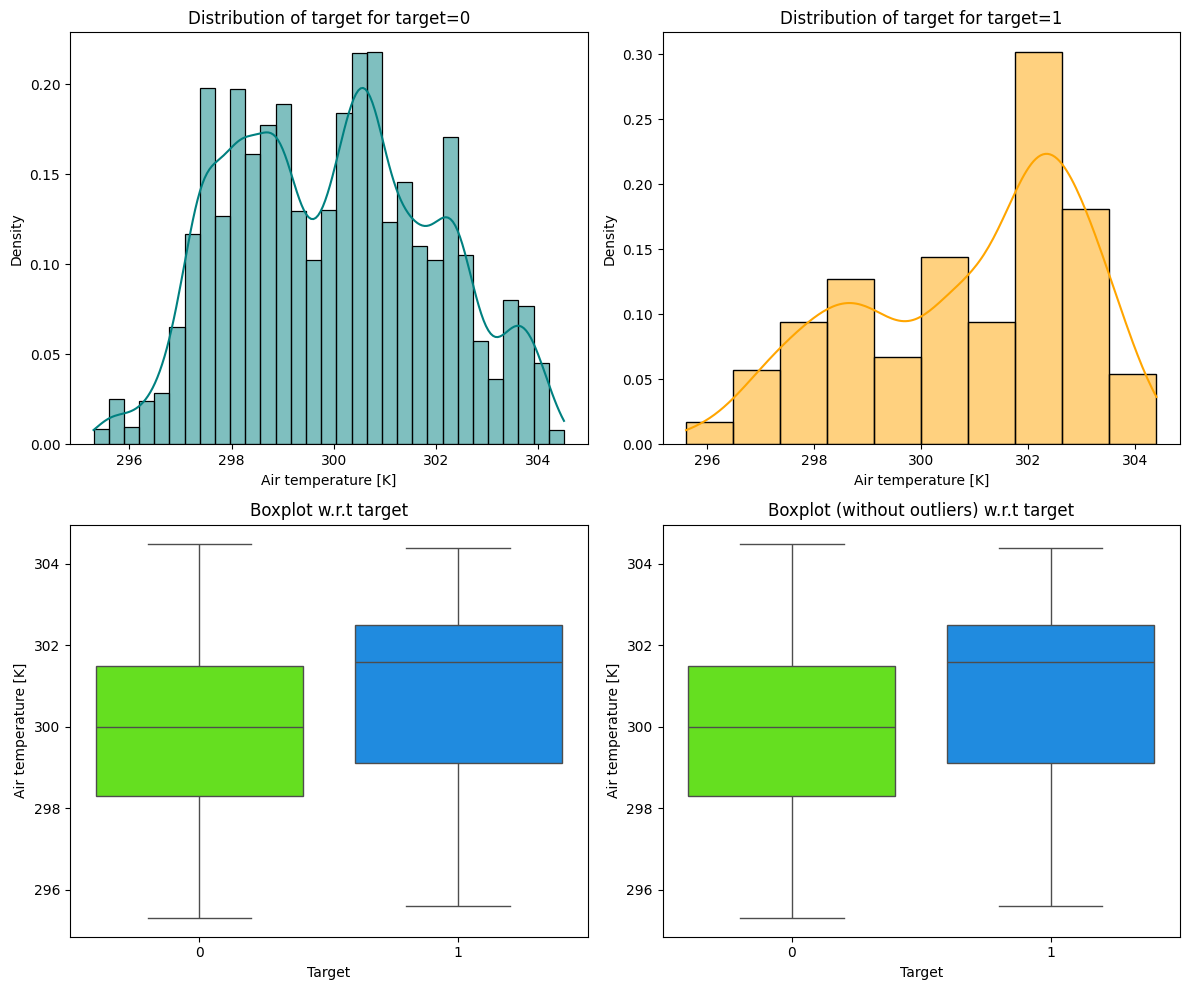

In [34]:
distribution_plot_wrt_target(df, 'Air temperature [K]', 'Target')

**Observation(s):**
- Average temperature of failed machines is clearly higher.
- Distributions are otherwise similar.

##### **target x Process temperature**

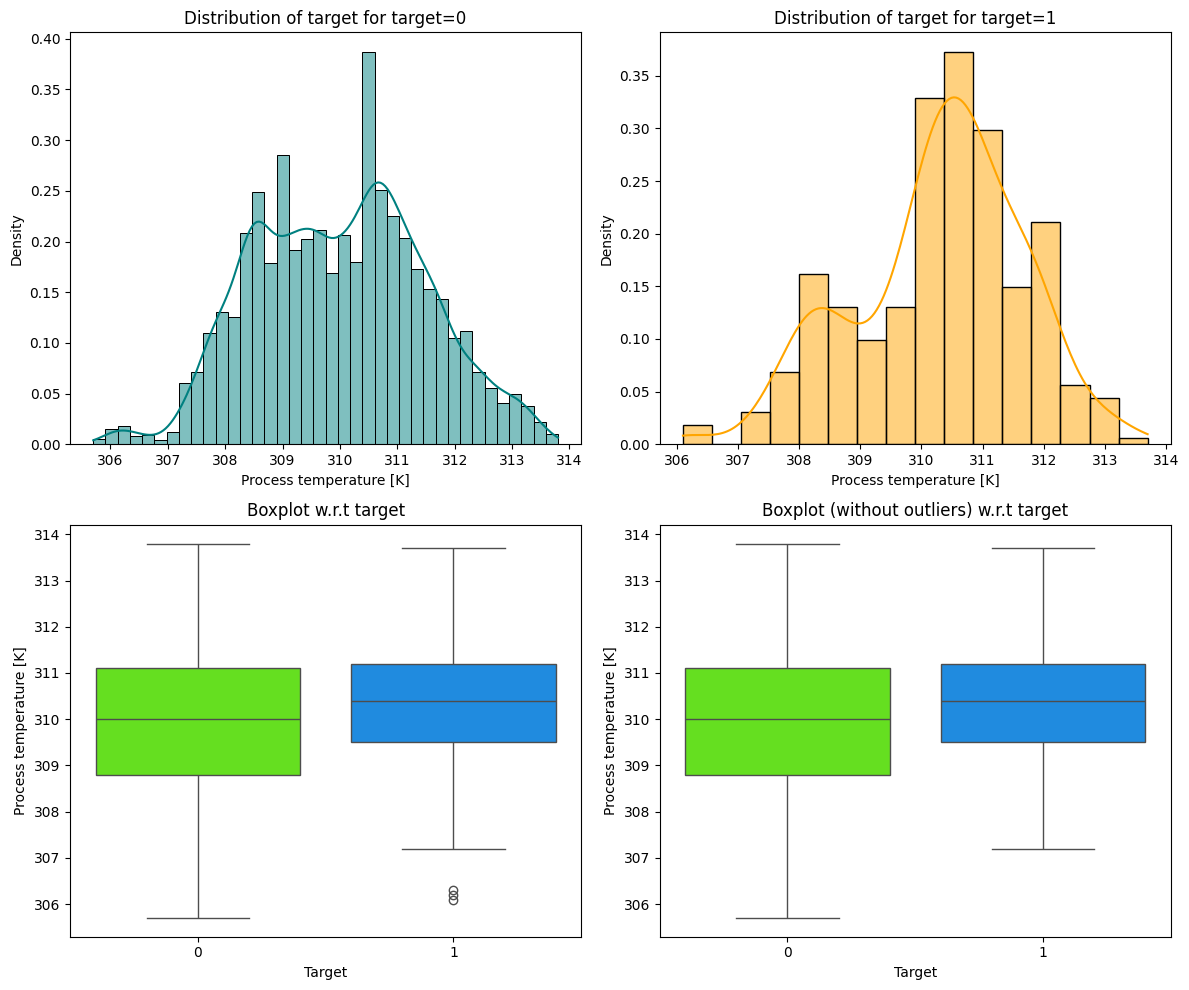

In [35]:
distribution_plot_wrt_target(df, 'Process temperature [K]', 'Target')

**Observation(s):**
- Very similar distributions, with larger cluster around 311 Kelvin in failed machines, compared to non-failed machines.

##### **target x Rotational speed**

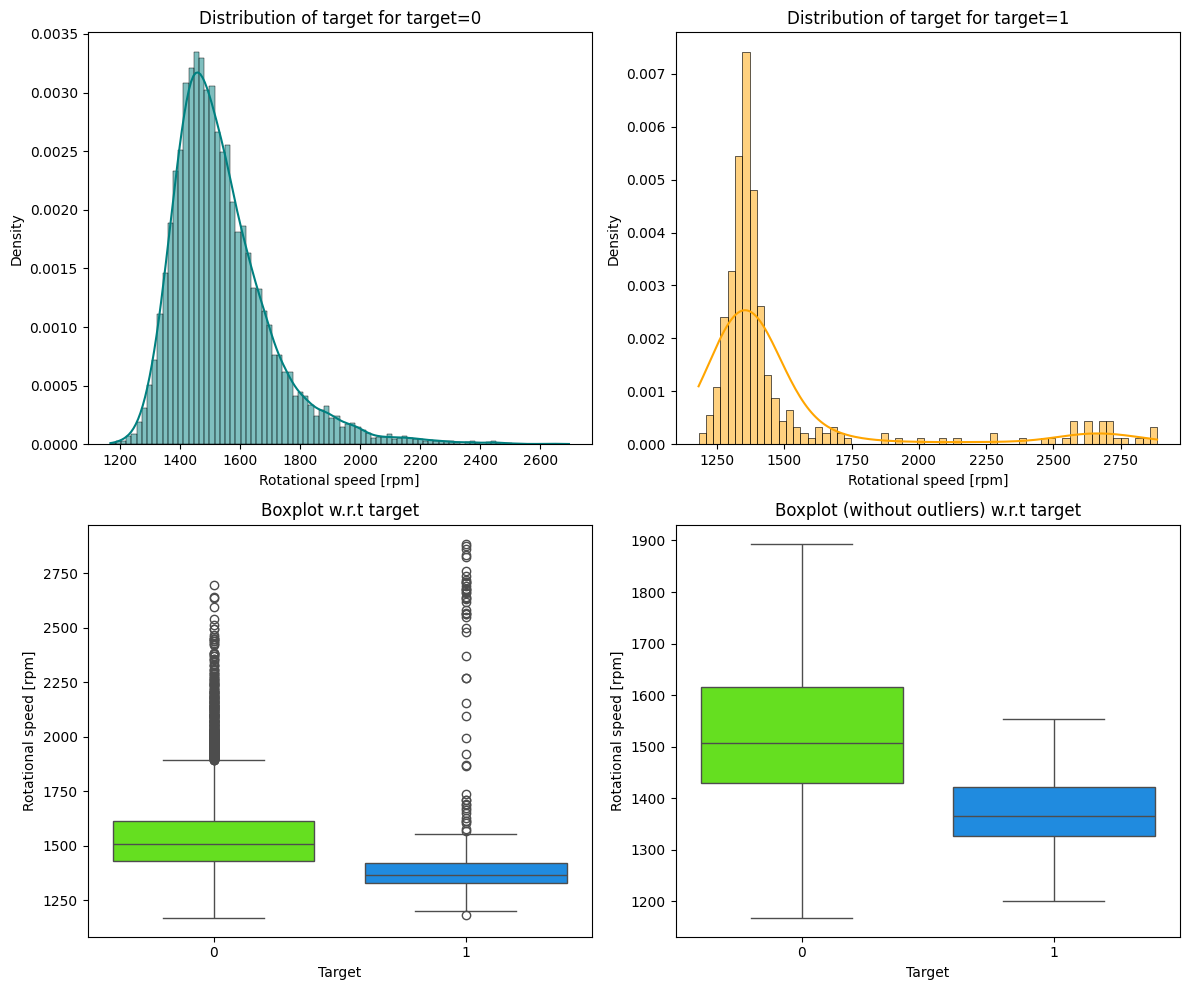

In [36]:
distribution_plot_wrt_target(df, 'Rotational speed [rpm]', 'Target')

**Observation(s):**
- Very similar distributions overall.
- More pronounced cluster around 2500-2800 in failed machines, compared to non-failed.

##### **target x Torque**

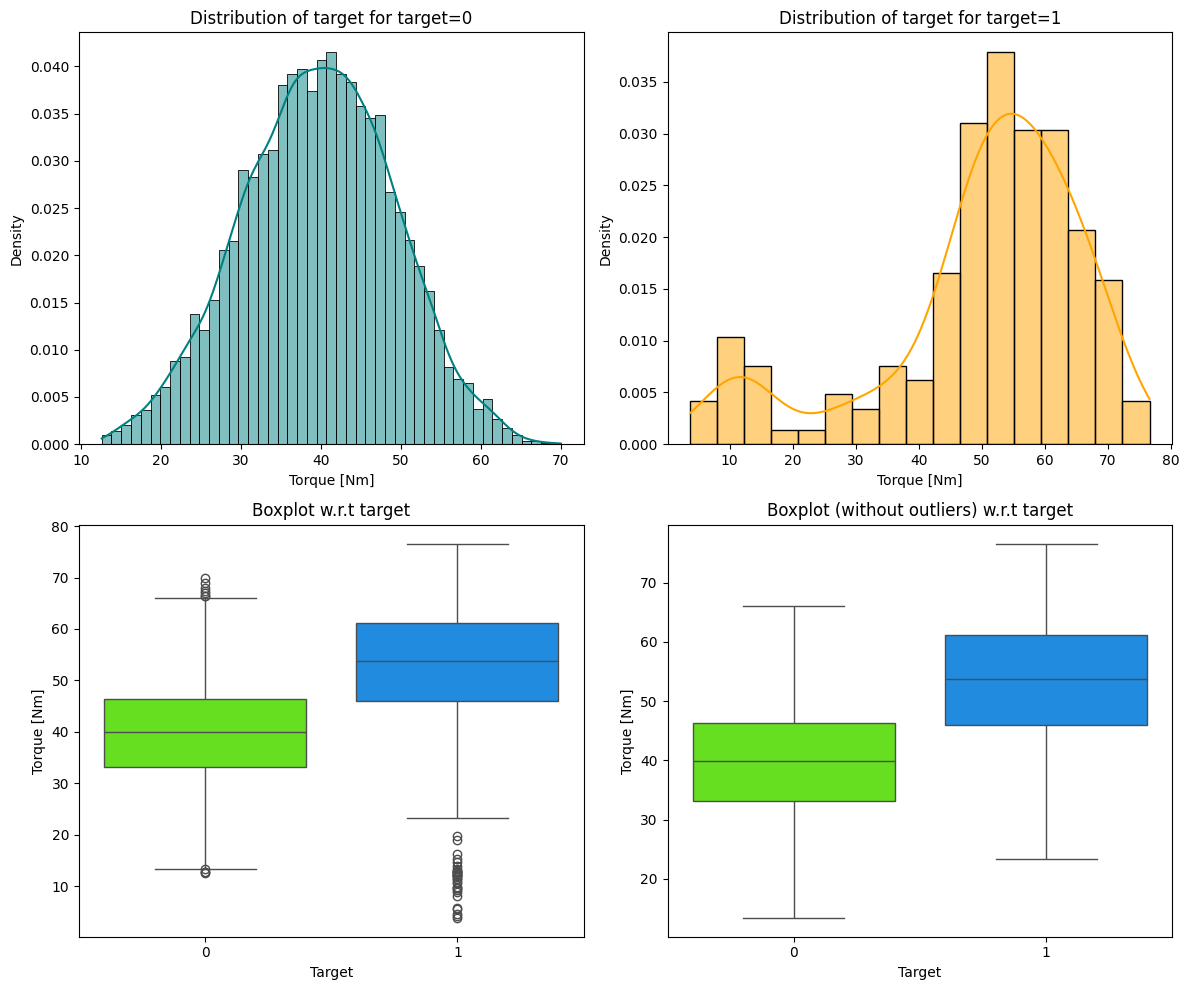

In [37]:
distribution_plot_wrt_target(df, 'Torque [Nm]', 'Target')

**Observation(s):**
- Distributions are completely different.
- Large cluster between 40-70 in failed machines.
- Mostly normal distribution for non-failed.

##### **target x Tool wear**

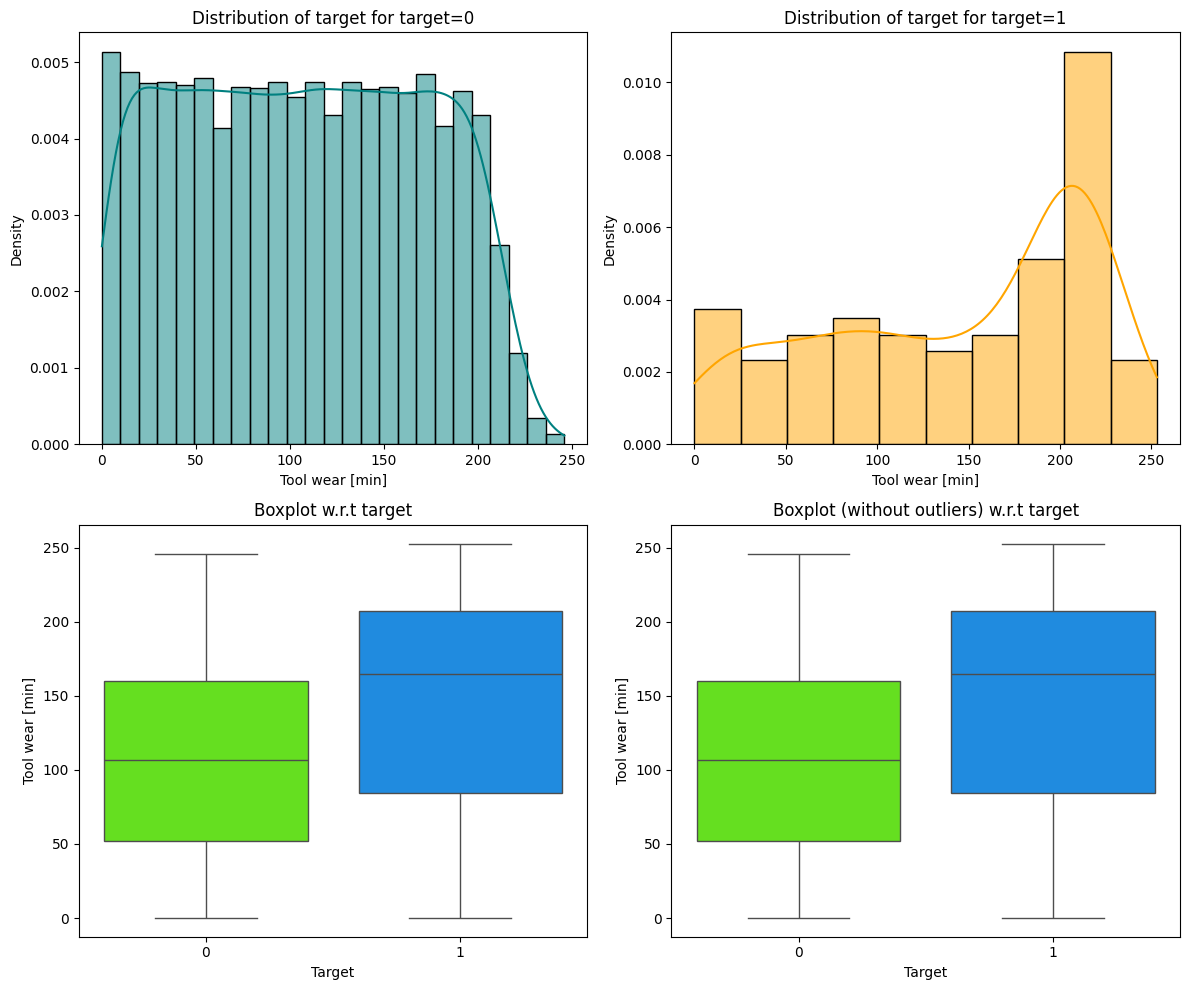

In [38]:
distribution_plot_wrt_target(df, 'Tool wear [min]', 'Target')

**Observation(s):**
- Distributions are complete opposites.
- Non-failed machines plateau until 200, then drop off.
- Failed machiens plateau until 200, then spike.

### **EDA Conclusion**

- All current features seem to have some correlation to the target variable.
- No reason to get rid of any more features.
- Greatest correlation seems to be with Tool wear.
- Could also be with Air temperature and/or Process temperature.
- Could create new columns, which indicate whether or not the machine is above a certain breakpoint for these three columns, using a boolean.

## **Feature Engineering**

### Normalization/Encoding

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Target                   10000 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB


#### Making Changes for Future Use

I don't necessarily want to go through with making the new column(s), without using the dataframe as-is first, so I'm just going to make a new version here, and use it later, if it seems like it might be helpful.

To be clear, I am going to make breakpoints for Air/Process temperature, and Tool wear.

In [40]:
df2 = df.copy()

# If Tool wear at/above 175
df2['wear_above_175'] = df2['Tool wear [min]'] >= 175
# If Process temperature at/above 310
df2['process_above_310'] = df2['Process temperature [K]'] >= 310
# If Air temperature at/above 301
df2['air_above_301'] = df2['Air temperature [K]'] >= 301

##### **Type**

In [41]:
# Encoding Type
df = pd.get_dummies(df, columns=['Type'], drop_first=True)
df2 = pd.get_dummies(df2, columns=['Type'], drop_first=True)

**Air temperature**

In [42]:
# Normalizing Air temperature
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['Air temperature [K]']])
df[['Air temperature [K]']] = scaler.transform(df[['Air temperature [K]']])
df2[['Air temperature [K]']] = scaler.transform(df2[['Air temperature [K]']])

**Process temperature**

In [43]:
scaler.fit(df[['Process temperature [K]']])
df[['Process temperature [K]']] = scaler.transform(df[['Process temperature [K]']])
df2[['Process temperature [K]']] = scaler.transform(df2[['Process temperature [K]']])

**Rotational speed**

In [44]:
scaler.fit(df[['Rotational speed [rpm]']])
df[['Rotational speed [rpm]']] = scaler.transform(df[['Rotational speed [rpm]']])
df2[['Rotational speed [rpm]']] = scaler.transform(df2[['Rotational speed [rpm]']])

**Torque**

In [45]:
scaler.fit(df[['Torque [Nm]']])
df[['Torque [Nm]']] = scaler.transform(df[['Torque [Nm]']])
df2[['Torque [Nm]']] = scaler.transform(df2[['Torque [Nm]']])

**Tool wear**

In [46]:
scaler.fit(df[['Tool wear [min]']])
df[['Tool wear [min]']] = scaler.transform(df[['Tool wear [min]']])
df2[['Tool wear [min]']] = scaler.transform(df2[['Tool wear [min]']])

In [47]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,0.511405,0.217419,0.0,0.326087,0.521739,0.673913,1.0
Process temperature [K],10000.0,0.531551,0.183177,0.0,0.382716,0.543210,0.666667,1.0
Rotational speed [rpm],10000.0,0.215818,0.104356,0.0,0.148428,0.194994,0.258440,1.0
Torque [Nm],10000.0,0.497073,0.136936,0.0,0.403846,0.498626,0.590659,1.0
Tool wear [min],10000.0,0.426684,0.251597,0.0,0.209486,0.426877,0.640316,1.0
Target,10000.0,0.033900,0.180981,0.0,0.000000,0.000000,0.000000,1.0


In [48]:
df.head(5)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Type_L,Type_M
0,0.304348,0.358025,0.222934,0.535714,0.000000,0,False,True
1,0.315217,0.370370,0.139697,0.583791,0.011858,0,True,False
2,0.304348,0.345679,0.192084,0.626374,0.019763,0,True,False
3,0.315217,0.358025,0.154249,0.490385,0.027668,0,True,False
4,0.315217,0.370370,0.139697,0.497253,0.035573,0,True,False


In [49]:
df2.head(5)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,wear_above_175,process_above_310,air_above_301,Type_L,Type_M
0,0.304348,0.358025,0.222934,0.535714,0.000000,0,False,False,False,False,True
1,0.315217,0.370370,0.139697,0.583791,0.011858,0,False,False,False,True,False
2,0.304348,0.345679,0.192084,0.626374,0.019763,0,False,False,False,True,False
3,0.315217,0.358025,0.154249,0.490385,0.027668,0,False,False,False,True,False
4,0.315217,0.370370,0.139697,0.497253,0.035573,0,False,False,False,True,False


## **Model Building - Iteration 1**

##### Functions

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
# function to compute different metrics to check performance of a regression model
def saveTestResults(model, pred, target, data, modelName, isTrain: bool):

    # predicting using the independent variables
    precision = precision_score(target, pred)
    recall = recall_score(target, pred)
    f1 = f1_score(target, pred)
    accuracy = accuracy_score(target, pred)

    df_perf = pd.DataFrame(
        {
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Accuracy": accuracy
        },
        index=[0],
    )
    
    # Storing results 
    if isTrain == False:
        data['Model'].append(modelName)
        data['Precision'].append(precision)
        data['Recall'].append(recall)
        data['F1 Score'].append(f1)
        data['Accuracy'].append(accuracy)    

    return df_perf

In [52]:
def getBestThreshold(model, pred, target, data, modelName):
    '''Function to compute optimal prediction threshold for given model'''
    
    # Get predicted probabilities for the positive class
    baseProbs = model.predict_proba(pred)[:, 1]
    
    threshold = 0.3
    
    results = {
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Accuracy': []
    }
    
    while True:
        customPred = (baseProbs >= threshold).astype(int)

        res = saveTestResults(model, customPred, target, data, modelName, isTrain=True)
        results['Precision'].append((res['Precision'][0], threshold))
        results['Recall'].append((res['Recall'][0], threshold))
        results['F1 Score'].append((res['F1 Score'][0], threshold))
        results['Accuracy'].append((res['Accuracy'][0], threshold))

        if threshold >= 0.99:
            break
        else:
            threshold = round(threshold + 0.01, 2)
            continue

    for key, value in results.items():
        results[key] = max(value)
    
    return results

In [53]:
def get_weights(model):
    '''Scores various combinations of class weights and outputs the results, 
    along with the strongest pair'''
    custom_weights = {0: 4, 1: 1}

    best_weights = {0: 4, 1: 1}
    best_score = 0
    
    results = {
    'Model': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Accuracy': []
    }
    for i in range(20):
        model.set_params(class_weight=custom_weights)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if len(results['F1 Score']) >= 2:
            try:
                if results['F1 Score'][-2] > results['F1 Score'][-1]:
                    best_weights[0] = float(results['Model'][-2].split(':')[0])
                    best_weights[1] = float(results['Model'][-2].split(':')[1])
                    best_score = results['F1 Score'][-2]
                    break
            except IndexError as e:
                print(e)
        
        custom_weights[0] = round(custom_weights[0] + 0.1, 1)
        custom_weights[1] = round(custom_weights[1] - 0.1, 1)

    while True:
        custom_weights[0] = round(custom_weights[0] + 0.1, 1)
        model.set_params(class_weight=custom_weights)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if best_score > results['F1 Score'][-1]:
            custom_weights[0] = best_weights[0]
            break
        elif best_score < results['F1 Score'][-1]:
            best_score = results['F1 Score'][-1]
            best_weights[0] = custom_weights[0]

    while True:
        custom_weights[0] = round(custom_weights[0] - 0.1, 1)
        model.set_params(class_weight=custom_weights)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if best_score > results['F1 Score'][-1]:
            custom_weights[0] = best_weights[0]
            break
        elif best_score < results['F1 Score'][-1]:
            best_score = results['F1 Score'][-1]
            best_weights[0] = custom_weights[0]

    while True:
        custom_weights[1] = round(custom_weights[1] + 0.1, 1)
        model.set_params(class_weight=custom_weights)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if best_score > results['F1 Score'][-1]:
            custom_weights[1] = best_weights[1]
            break
        elif best_score < results['F1 Score'][-1]:
            best_score = results['F1 Score'][-1]
            best_weights[1] = custom_weights[1]

    while True:
        custom_weights[1] = round(custom_weights[1] - 0.1, 1)
        model.set_params(class_weight=custom_weights)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if best_score > results['F1 Score'][-1]:
            custom_weights[1] = best_weights[1]
            break
        elif best_score < results['F1 Score'][-1]:
            best_score = results['F1 Score'][-1]
            best_weights[1] = custom_weights[1]
    
    return results

In [54]:
resultsDict1 = {
    'Model': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Accuracy': []
}

### **Random Forest**

In [55]:
X = df.drop(['Target'], axis=1)

In [56]:
y = df['Target']
y = y.astype(bool)

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score, accuracy_score

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [59]:
from sklearn.ensemble import RandomForestClassifier

In [60]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

trainPred = rf.predict(X_train)
rfTrainResults = saveTestResults(rf, trainPred, y_train, resultsDict1, "RandomForest Vanilla", isTrain=True)
rfTrainResults

,Precision,Recall,F1 Score,Accuracy
0,1.0,1.0,1.0,1.0


In [61]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
rfTrainResults = saveTestResults(rf, pred, y_test, resultsDict1, "RandomForest Vanilla", isTrain=False)
rfTrainResults

,Precision,Recall,F1 Score,Accuracy
0,0.887097,0.591398,0.709677,0.985


In [62]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_test, pred)
matrix = pd.DataFrame(matrix, index=['Negative', 'Positive'],
                              columns=['Negative', 'Positive'])
print(matrix)

          Negative  Positive
Negative      2900         7
Positive        38        55


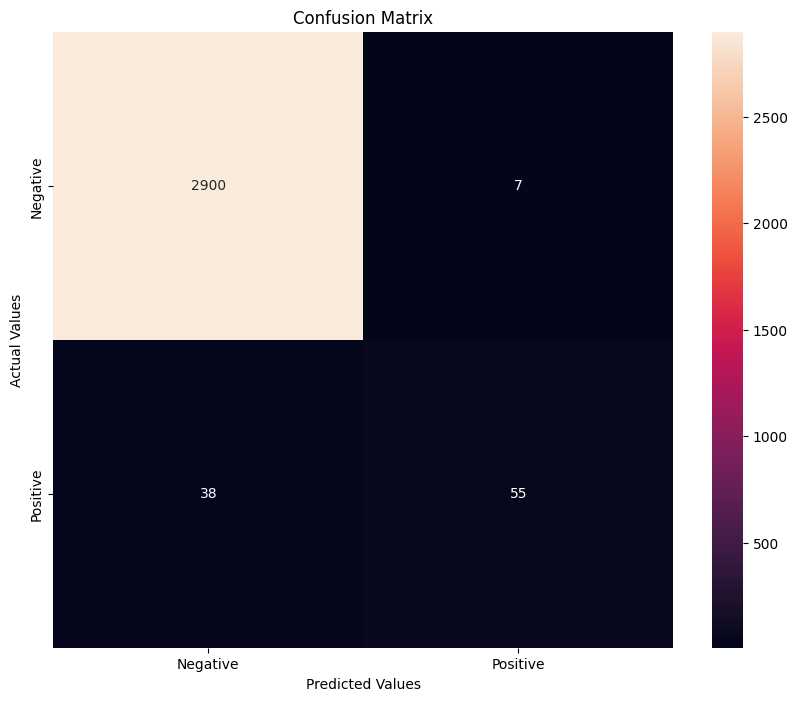

In [63]:
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True, fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

### Refinement

#### Class Weight

**Balanced**

In [64]:
rf.set_params(class_weight='balanced')
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

rfWeightResults = saveTestResults(rf, pred, y_test, resultsDict1, "RandomForest Weighted", isTrain=False)
rfWeightResults

,Precision,Recall,F1 Score,Accuracy
0,0.9,0.387097,0.541353,0.979667


- Using 'balanced' led to an improvement in precision, but a massive setback everywhere else, so we'll try using custom weights.

**Custom**

In [65]:
from sklearn.model_selection import GridSearchCV

In [66]:
params = {
    'class_weight': [{0: 1, 1: 1}, 
                     {0: 1, 1: 1.5}, 
                     {0: 1, 1: 2},
                     {0: 1, 1: 4},
                     {0: 1.5, 1: 1},
                     {0: 2, 1: 1},
                     {0: 4, 1: 1}]
}

In [67]:
# Initialize GridSearchCV with scoring based on F1 score
grid_search = GridSearchCV(estimator=rf, param_grid=params, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'class_weight': {0: 2, 1: 1}}

Now, I'll use the custom function, starting from these weights, and see the refined results.

In [68]:
weights = get_weights(rf)
weights = pd.DataFrame(weights)
weights

,Model,Precision,Recall,F1 Score,Accuracy
0,4:1,0.904762,0.612903,0.730769,0.986000
1,4.1:0.9,0.919355,0.612903,0.735484,0.986333
2,4.2:0.8,0.920635,0.623656,0.743590,0.986667
3,4.3:0.7,0.921875,0.634409,0.751592,0.987000
4,4.4:0.6,0.909091,0.645161,0.754717,0.987000
5,4.5:0.5,0.907692,0.634409,0.746835,0.986667
6,4.6:0.5,0.937500,0.645161,0.764331,0.987667
7,4.7:0.5,0.904762,0.612903,0.730769,0.986000
8,4.5:0.5,0.907692,0.634409,0.746835,0.986667
9,4.6:0.6,0.919355,0.612903,0.735484,0.986333


It looks like 2.1 and 0.9 are the best weights to use, for F1 score.

#### Prediction Threshold

In [69]:
warnings.filterwarnings('ignore')
rf.set_params(class_weight={0: 2.1, 1: 0.9})
rf.fit(X_train, y_train)

bestThresh = getBestThreshold(rf, X_test, y_test, resultsDict1, "RandomForest")
bestThresh

{'Precision': (1.0, 0.96),
 'Recall': (0.7634408602150538, 0.3),
 'F1 Score': (0.7636363636363637, 0.42),
 'Accuracy': (0.987, 0.53)}

In [70]:
baseProb = rf.predict_proba(X_test)[:, 1]
threshold = 0.42
customPred = (baseProb >= threshold).astype(int)

threshResults = saveTestResults(rf, customPred, y_test, resultsDict1, "RandomForest Threshold", isTrain=False)
threshResults

,Precision,Recall,F1 Score,Accuracy
0,0.875,0.677419,0.763636,0.987


In [71]:
matrix = confusion_matrix(y_test, customPred)
matrix = pd.DataFrame(matrix, index=['Negative', 'Positive'],
                              columns=['Negative', 'Positive'])
print(matrix)

          Negative  Positive
Negative      2898         9
Positive        30        63


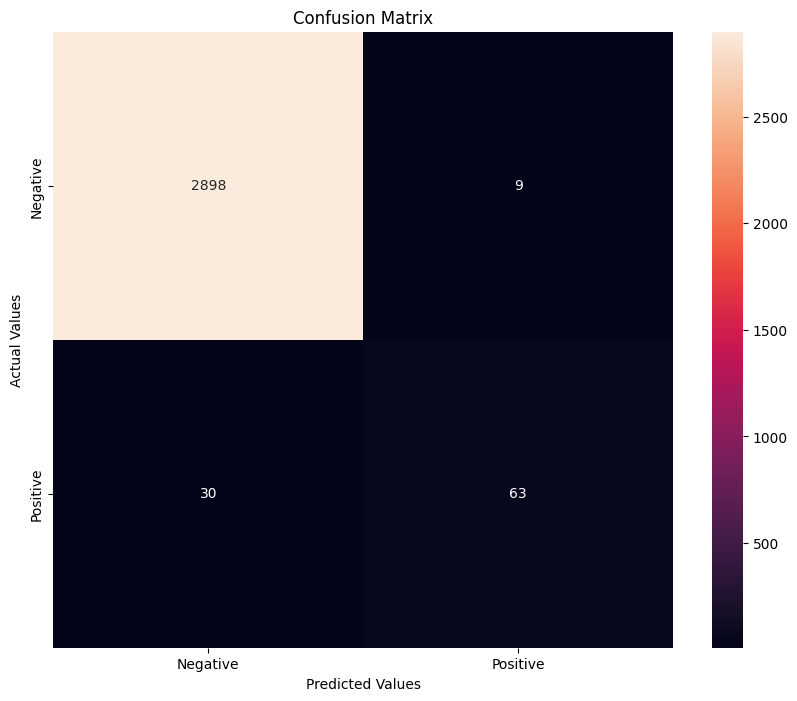

In [72]:
# Plotting the confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

#### Larger Test Split

Due to the rather large difference in results between training and test results, I think it makes sense to increase the size of the test split.

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [74]:
rf2 = RandomForestClassifier(random_state=42, n_jobs=-1)
rf2.fit(X_train, y_train)

trainPred = rf2.predict(X_train)
rfTrainResults2 = saveTestResults(rf2, trainPred, y_train, resultsDict1, "RandomForest LargeTest", isTrain=True)
rfTrainResults2

,Precision,Recall,F1 Score,Accuracy
0,1.0,1.0,1.0,1.0


In [75]:
rf2 = RandomForestClassifier(random_state=42, n_jobs=-1)
rf2.fit(X_train, y_train)

pred = rf2.predict(X_test)
rfTrainResults2 = saveTestResults(rf2, pred, y_test, resultsDict1, "RandomForest LargeTest", isTrain=False)
rfTrainResults2

,Precision,Recall,F1 Score,Accuracy
0,0.896104,0.534884,0.669903,0.983


In [76]:
matrix = confusion_matrix(y_test, pred)
matrix = pd.DataFrame(matrix, index=['Negative', 'Positive'],
                              columns=['Negative', 'Positive'])
print(matrix)

          Negative  Positive
Negative      3863         8
Positive        60        69


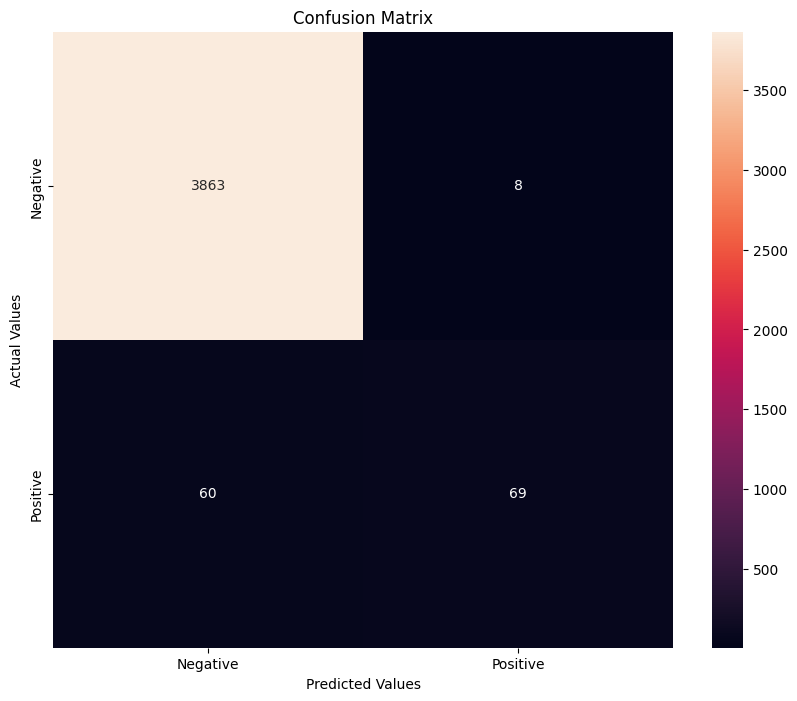

In [77]:
# Plotting the confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

Obviously, this is a step in the wrong direction.

#### Class Weight

**Balanced**

In [78]:
rf2.set_params(class_weight='balanced')
rf2.fit(X_train, y_train)

pred = rf2.predict(X_test)

rfWeightResults = saveTestResults(rf2, pred, y_test, resultsDict1, "RandomForest Large Weight", isTrain=False)
rfWeightResults

,Precision,Recall,F1 Score,Accuracy
0,0.866667,0.403101,0.550265,0.97875


- Using 'balanced' led to a massive setback everywhere, so we'll try using custom weights.

**Custom**

In [79]:
params = {
    'class_weight': [{0: 1, 1: 1}, 
                     {0: 1, 1: 1.5}, 
                     {0: 1, 1: 2},
                     {0: 1, 1: 4},
                     {0: 1.5, 1: 1},
                     {0: 2, 1: 1},
                     {0: 4, 1: 1}]
}

In [80]:
# Initialize GridSearchCV with scoring based on F1 score
grid_search = GridSearchCV(estimator=rf2, param_grid=params, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'class_weight': {0: 1, 1: 1}}

Now, I'll use the custom function, starting from these weights, and see the refined results.

In [81]:
weights = get_weights(rf2)
weights = pd.DataFrame(weights)
weights

,Model,Precision,Recall,F1 Score,Accuracy
0,4:1,0.882353,0.581395,0.700935,0.98400
1,4.1:0.9,0.916667,0.596899,0.723005,0.98525
2,4.2:0.8,0.892857,0.581395,0.704225,0.98425
3,4.3:0.8,0.896552,0.604651,0.722222,0.98500
4,4.0:0.8,0.894118,0.589147,0.710280,0.98450
5,4.1:0.9,0.916667,0.596899,0.723005,0.98525
6,4.1:1.0,0.891566,0.573643,0.698113,0.98400
7,4.1:0.8,0.895349,0.596899,0.716279,0.98475


#### Usage of SMOTE

In [82]:
from imblearn.over_sampling import SMOTE

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [84]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [85]:
rfSMOTE = RandomForestClassifier(random_state=42, n_jobs=-1)
rfSMOTE.fit(X_train_smote, y_train_smote)
pred = rfSMOTE.predict(X_test)

smoteResults = saveTestResults(rfSMOTE, pred, y_test, resultsDict1, "RandomForest SMOTE", isTrain=False)
smoteResults

,Precision,Recall,F1 Score,Accuracy
0,0.496552,0.774194,0.605042,0.968667


#### Pipeline

In [86]:
param_grid = {
    'smote__sampling_strategy': ['auto', 0.5, 0.6, 0.7],
    'randomforestclassifier__n_estimators': [100, 200, 300, 400],
    'randomforestclassifier__max_depth': [None, 10, 20]
}

In [87]:
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ('smote', SMOTE()),
    ('randomforestclassifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [88]:
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'randomforestclassifier__max_depth': 20,
 'randomforestclassifier__n_estimators': 300,
 'smote__sampling_strategy': 0.5}

#### Pipeline 2

In [89]:
param_grid = {
    'smote__sampling_strategy': ['auto', 0.3, 0.4, 0.5],
    'randomforestclassifier__n_estimators': [350, 400, 450, 500],
    'randomforestclassifier__max_depth': [15, 20, 25]
}

In [90]:
pipeline = Pipeline([
    ('smote', SMOTE()),
    ('randomforestclassifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [91]:
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_params

{'randomforestclassifier__max_depth': 25,
 'randomforestclassifier__n_estimators': 350,
 'smote__sampling_strategy': 0.3}

In [92]:
best_params

{'randomforestclassifier__max_depth': 25,
 'randomforestclassifier__n_estimators': 350,
 'smote__sampling_strategy': 0.3}

In [93]:
best_params = grid_search.best_params_

rfSMOTE = RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=25, n_estimators=350)
smote = SMOTE(random_state=42, sampling_strategy=0.3)

best_pipe = Pipeline([
    ('smote', smote),
    ('randomforestclassifier', rfSMOTE)
])

In [94]:
best_pipe.fit(X_train, y_train)

pred = best_pipe.predict(X_test)

rfPipeResults = saveTestResults(best_pipe, pred, y_test, resultsDict1, "RandomForest Pipeline", isTrain=False)
rfPipeResults

,Precision,Recall,F1 Score,Accuracy
0,0.65,0.698925,0.673575,0.979


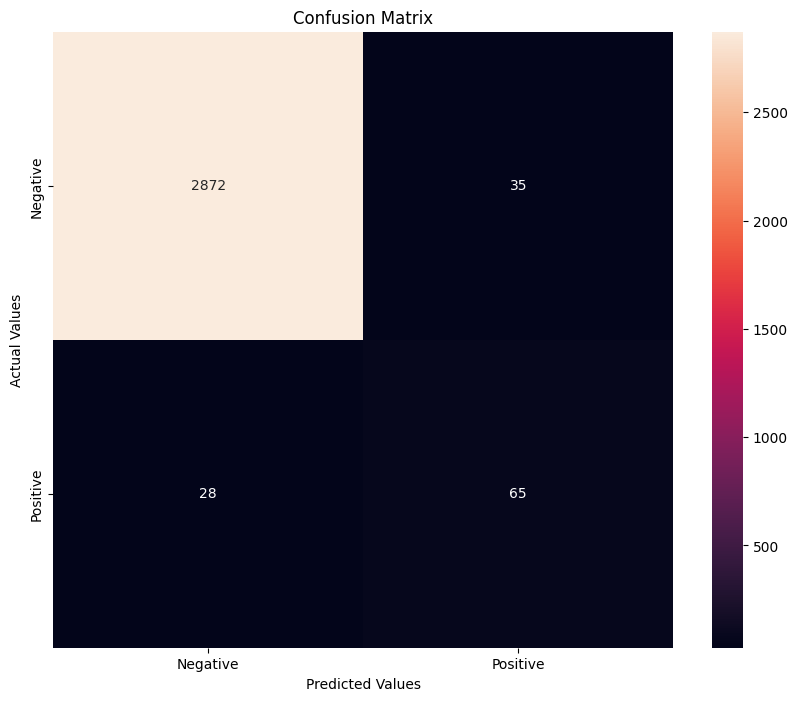

In [95]:
matrix = confusion_matrix(y_test, pred)
matrix = pd.DataFrame(matrix, index=['Negative', 'Positive'],
                              columns=['Negative', 'Positive'])
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

Significant improvement over just using SMOTE, but still not in the realm that we want it to be. Because of the lack of positive results, I'm going to move on to the next iteration.

## **Model Building - Iteration 2**

As stated previously, I will be using a different version of the dataset for this iteration, which includes a couple of new columns.

In [96]:
df2.head(5)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,wear_above_175,process_above_310,air_above_301,Type_L,Type_M
0,0.304348,0.358025,0.222934,0.535714,0.000000,0,False,False,False,False,True
1,0.315217,0.370370,0.139697,0.583791,0.011858,0,False,False,False,True,False
2,0.304348,0.345679,0.192084,0.626374,0.019763,0,False,False,False,True,False
3,0.315217,0.358025,0.154249,0.490385,0.027668,0,False,False,False,True,False
4,0.315217,0.370370,0.139697,0.497253,0.035573,0,False,False,False,True,False


In [97]:
resultsDict2 = {
    'Model': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Accuracy': []
}

In [98]:
X = df2.drop(['Target'], axis=1)
y = df2['Target']
y = y.astype(bool)

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Random Forest**

In [100]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

trainPred = rf.predict(X_train)
rfTrainResults = saveTestResults(rf, trainPred, y_train, resultsDict2, "RandomForest Vanilla2", isTrain=True)
rfTrainResults

,Precision,Recall,F1 Score,Accuracy
0,1.0,1.0,1.0,1.0


In [101]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
rfTestResults = saveTestResults(rf, pred, y_test, resultsDict2, "RandomForest Vanilla2", isTrain=False)
rfTestResults

,Precision,Recall,F1 Score,Accuracy
0,0.904762,0.612903,0.730769,0.986


In [102]:
# First results from previous iteration
print(f"Precision: {resultsDict1['Precision'][0]}")
print(f"Recall: {resultsDict1['Recall'][0]}")
print(f"F1: {resultsDict1['F1 Score'][0]}")
print(f"Accuracy: {resultsDict1['Accuracy'][0]}")

Precision: 0.8870967741935484
Recall: 0.5913978494623656
F1: 0.7096774193548387
Accuracy: 0.985


Comparing to the first results of the previous iteration, we can see that the this iteration is superior in all metrics, especially F1.

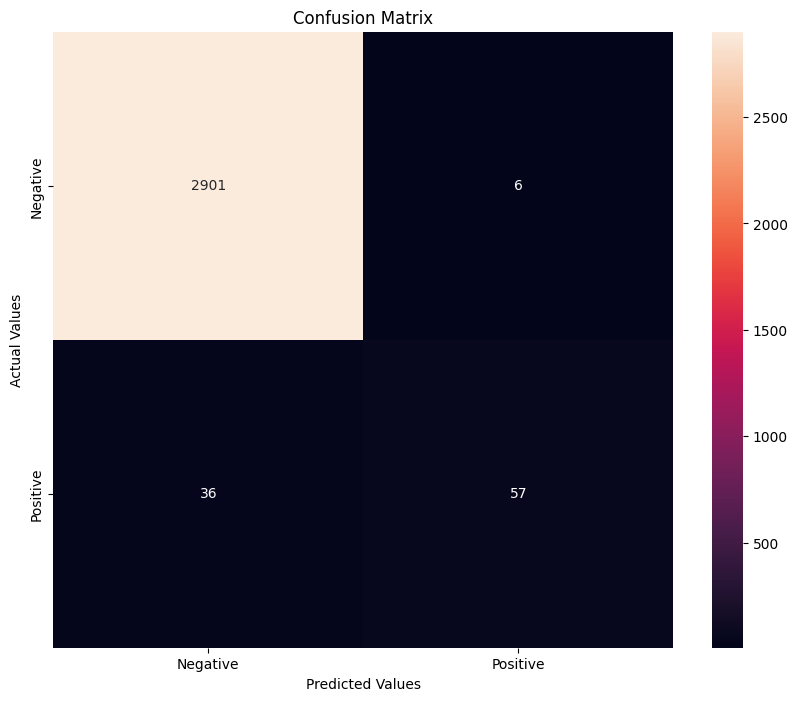

In [103]:
matrix = confusion_matrix(y_test, pred)
matrix = pd.DataFrame(matrix, index=['Negative', 'Positive'],
                              columns=['Negative', 'Positive'])
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

### Refinement

#### Class Weight

**Balanced**

In [104]:
rf.set_params(class_weight='balanced')
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

rfWeightResults = saveTestResults(rf, pred, y_test, resultsDict1, "RandomForest Weighted2", isTrain=False)
rfWeightResults

,Precision,Recall,F1 Score,Accuracy
0,0.921053,0.376344,0.534351,0.979667


Clearly, this is worse, so let's try with custom weights.

**Custom**

In [105]:
params = {
    'class_weight': [{0: 1, 1: 1}, 
                     {0: 1, 1: 1.5}, 
                     {0: 1, 1: 2},
                     {0: 1, 1: 4},
                     {0: 1.5, 1: 1},
                     {0: 2, 1: 1},
                     {0: 3, 1: 1},
                     {0: 4, 1: 1}]
}

In [106]:
# Initialize GridSearchCV with scoring based on F1 score
grid_search = GridSearchCV(estimator=rf, param_grid=params, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'class_weight': {0: 4, 1: 1}}

Now, I'll use the custom function, starting from these weights, and see the refined results.

In [107]:
weights = get_weights(rf)
weights = pd.DataFrame(weights)
weights

,Model,Precision,Recall,F1 Score,Accuracy
0,4:1,0.911765,0.666667,0.770186,0.987667
1,4.1:0.9,0.907692,0.634409,0.746835,0.986667
2,4.2:0.9,0.906250,0.623656,0.738854,0.986333
3,3.9:0.9,0.938462,0.655914,0.772152,0.988000
4,3.8:0.9,0.936508,0.634409,0.756410,0.987333
5,3.9:1.0,0.924242,0.655914,0.767296,0.987667
6,3.9:0.9,0.938462,0.655914,0.772152,0.988000
7,3.9:0.8,0.936508,0.634409,0.756410,0.987333


3.9 and 0.9 seem to be the best weights, so that's what we will use going forward.

#### Usage of SMOTE

In [108]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [109]:
rfSMOTE = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight={0: 3.9, 1: 0.9})
rfSMOTE.fit(X_train_smote, y_train_smote)

pred = rfSMOTE.predict(X_test)

rfSmoteResults = saveTestResults(rfSMOTE, pred, y_test, resultsDict2, "RandomForest SMOTE2", isTrain=False)
rfSmoteResults

,Precision,Recall,F1 Score,Accuracy
0,0.484277,0.827957,0.611111,0.967333


#### Prediction Threshold

In [110]:
rf.set_params(class_weight={0: 2.1, 1: 0.9})
rf.fit(X_train, y_train)

bestThresh = getBestThreshold(rf, X_test, y_test, resultsDict2, "RandomForest")
bestThresh

{'Precision': (1.0, 0.96),
 'Recall': (0.7849462365591398, 0.31),
 'F1 Score': (0.8114285714285714, 0.38),
 'Accuracy': (0.9893333333333333, 0.41)}

In [111]:
baseProb = rf.predict_proba(X_test)[:, 1]
threshold = 0.38
customPred = (baseProb >= threshold).astype(int)

threshResults = saveTestResults(rf, customPred, y_test, resultsDict2, "RandomForest Threshold", isTrain=False)
threshResults

,Precision,Recall,F1 Score,Accuracy
0,0.865854,0.763441,0.811429,0.989


These results are fairly satisfying, given how severely unbalanced the dataset is, however I still think we cand o better.

#### Pipeline

In [112]:
param_grid = {
    'smote__sampling_strategy': ['auto', 0.3, 0.5, 0.7],
    'randomforestclassifier__n_estimators': [200, 300, 400, 500],
    'randomforestclassifier__max_depth': [10, 15, 20]
}

In [113]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('randomforestclassifier', rf)
])

In [114]:
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_params

{'randomforestclassifier__max_depth': 10,
 'randomforestclassifier__n_estimators': 200,
 'smote__sampling_strategy': 0.3}

In [115]:
rfSMOTE = RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=10, n_estimators=200,
                                 class_weight={0: 3.9, 1: 0.9})
smote = SMOTE(random_state=42, sampling_strategy=0.3)

best_pipe = Pipeline([
    ('smote', smote),
    ('randomforestclassifier', rfSMOTE)
])

In [116]:
best_pipe.fit(X_train, y_train)

pred = best_pipe.predict(X_test)

rfPipeResults = saveTestResults(best_pipe, pred, y_test, resultsDict2, "RandomForest Pipeline2", isTrain=False)
rfPipeResults

,Precision,Recall,F1 Score,Accuracy
0,0.72043,0.72043,0.72043,0.982667


#### Pipeline Threshold

In [117]:
bestThresh = getBestThreshold(best_pipe, X_test, y_test, resultsDict2, "RandomForest")
bestThresh

{'Precision': (1.0, 0.98),
 'Recall': (0.8602150537634409, 0.32),
 'F1 Score': (0.7362637362637363, 0.52),
 'Accuracy': (0.984, 0.63)}

It was worth a shot, but using pipeline here is clearly not beneficial, compared to the results when not using it.

### **XGBoost**

In [118]:
def getBestDepth(model, X_train, y_train):
    '''Function to compute optimal max_depth for XGBoost'''
    
    depth = 1
    
    results = {
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Accuracy': []
    }
    
    while True:
        model.set_params(max_depth=depth)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        res = saveTestResults(model, y_pred, y_test, resultsDict1, "XGBoost", isTrain=True)
        results['Precision'].append((res['Precision'][0], depth))
        results['Recall'].append((res['Recall'][0], depth))
        results['F1 Score'].append((res['F1 Score'][0], depth))
        results['Accuracy'].append((res['Accuracy'][0], depth))

        if depth >= 10:
            break
        else:
            depth = round(depth + 1, 2)
            continue

    for key, value in results.items():
        results[key] = max(value)
    
    return results

In [119]:
def getBestLearn(model, X_train, y_train, lowerBound, upperBound):
    '''Function to compute optimal max_depth for XGBoost'''
    
    learn = lowerBound
    
    results = {
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Accuracy': []
    }
    
    while True:
        model.set_params(learning_rate=learn)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        res = saveTestResults(model, y_pred, y_test, resultsDict1, "XGBoost", isTrain=True)
        results['Precision'].append((res['Precision'][0], learn))
        results['Recall'].append((res['Recall'][0], learn))
        results['F1 Score'].append((res['F1 Score'][0], learn))
        results['Accuracy'].append((res['Accuracy'][0], learn))

        if learn >= upperBound:
            break
        else:
            learn = round(learn + 0.01, 3)
            continue

    for key, value in results.items():
        results[key] = max(value)

    print("hi")
    return results

In [120]:
def get_weights(model):
    '''Scores various combinations of class weights and outputs the results, 
    along with the strongest pair'''
    custom_weights = {0: 0.1, 1: 2}

    best_weights = {0: 0.1, 1: 2}
    best_score = 0
    
    results = {
    'Model': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Accuracy': []
    }
    for i in range(20):
        model.set_params(class_weight=custom_weights)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if len(results['F1 Score']) >= 2:
            try:
                if results['F1 Score'][-2] > results['F1 Score'][-1]:
                    best_weights[0] = float(results['Model'][-2].split(':')[0])
                    best_weights[1] = float(results['Model'][-2].split(':')[1])
                    best_score = results['F1 Score'][-2]
                    break
            except IndexError as e:
                print(e)
        
        custom_weights[0] = round(custom_weights[0] + 0.1, 1)
        custom_weights[1] = round(custom_weights[1] - 0.1, 1)

    while True:
        custom_weights[0] = round(custom_weights[0] + 0.1, 1)
        model.set_params(class_weight=custom_weights)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if best_score > results['F1 Score'][-1]:
            custom_weights[0] = best_weights[0]
            break
        elif best_score < results['F1 Score'][-1]:
            best_score = results['F1 Score'][-1]
            best_weights[0] = custom_weights[0]

    while True:
        custom_weights[0] = round(custom_weights[0] - 0.1, 1)
        model.set_params(class_weight=custom_weights)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if best_score > results['F1 Score'][-1]:
            custom_weights[0] = best_weights[0]
            break
        elif best_score < results['F1 Score'][-1]:
            best_score = results['F1 Score'][-1]
            best_weights[0] = custom_weights[0]

    while True:
        custom_weights[1] = round(custom_weights[1] + 0.1, 1)
        model.set_params(class_weight=custom_weights)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if best_score > results['F1 Score'][-1]:
            custom_weights[1] = best_weights[1]
            break
        elif best_score < results['F1 Score'][-1]:
            best_score = results['F1 Score'][-1]
            best_weights[1] = custom_weights[1]

    while True:
        custom_weights[1] = round(custom_weights[1] - 0.1, 1)
        model.set_params(class_weight=custom_weights)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if best_score > results['F1 Score'][-1]:
            custom_weights[1] = best_weights[1]
            break
        elif best_score < results['F1 Score'][-1]:
            best_score = results['F1 Score'][-1]
            best_weights[1] = custom_weights[1]
    
    return results

In [121]:
import re
from xgboost import XGBClassifier

In [122]:
# Column names can't contain special characters with XGBoost
df2.columns = [re.sub(r'[\[\]<>]', '', col) for col in df2.columns]

In [123]:
X = df2.drop(['Target'], axis=1)
y = df2['Target']
y = y.astype(bool)

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [125]:
xg = XGBClassifier(random_state=42)
xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [126]:
trainPred = xg.predict(X_train)

xgTrainResults = saveTestResults(xg, trainPred, y_train, resultsDict2, "XGBoost Vanilla", isTrain=True)
xgTrainResults

,Precision,Recall,F1 Score,Accuracy
0,1.0,1.0,1.0,1.0


In [127]:
pred = xg.predict(X_test)

xgTestResults = saveTestResults(xg, pred, y_test, resultsDict2, "XGBoost Vanilla", isTrain=False)
xgTestResults

,Precision,Recall,F1 Score,Accuracy
0,0.875,0.677419,0.763636,0.987


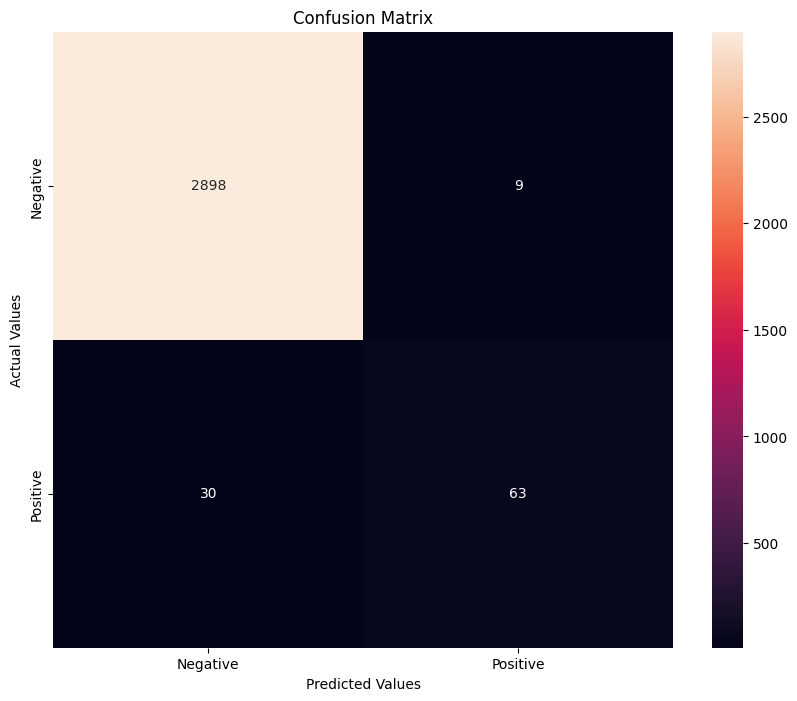

In [128]:
matrix = confusion_matrix(y_test, pred)
matrix = pd.DataFrame(matrix, index=['Negative', 'Positive'],
                              columns=['Negative', 'Positive'])
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

Promising results to start off.

### Refinement

#### Max Depth

In [129]:
bestDepth = getBestDepth(xg, X_train, y_train)
bestDepth

{'Precision': (0.9, 9),
 'Recall': (0.6881720430107527, 10),
 'F1 Score': (0.7757575757575758, 10),
 'Accuracy': (0.9876666666666667, 10)}

In [130]:
xg.set_params(max_depth=10)
xg.fit(X_train, y_train)
pred = xg.predict(X_test)

xgDepthResults = saveTestResults(xg, pred, y_test, resultsDict2, "XGBoost Depth", isTrain=False)
xgDepthResults

,Precision,Recall,F1 Score,Accuracy
0,0.888889,0.688172,0.775758,0.987667


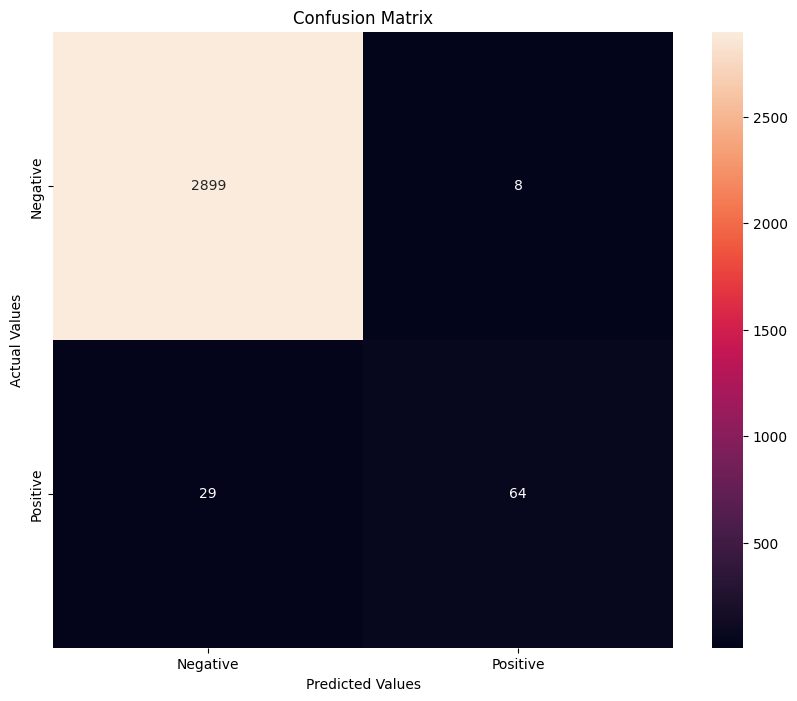

In [131]:
matrix = confusion_matrix(y_test, pred)
matrix = pd.DataFrame(matrix, index=['Negative', 'Positive'],
                              columns=['Negative', 'Positive'])
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

#### Learning Rate

In [132]:
bestLearn = getBestLearn(xg, X_train, y_train, 0.1, 1)
bestLearn

hi


{'Precision': (0.9130434782608695, 0.36),
 'Recall': (0.7204301075268817, 0.31),
 'F1 Score': (0.7976190476190477, 0.31),
 'Accuracy': (0.9886666666666667, 0.31)}

In [133]:
xg.set_params(learning_rate=0.31)
xg.fit(X_train, y_train)
pred = xg.predict(X_test)

xgLearnResults = saveTestResults(xg, pred, y_test, resultsDict2, "XGBoost Learn", isTrain=False)
xgLearnResults

,Precision,Recall,F1 Score,Accuracy
0,0.893333,0.72043,0.797619,0.988667


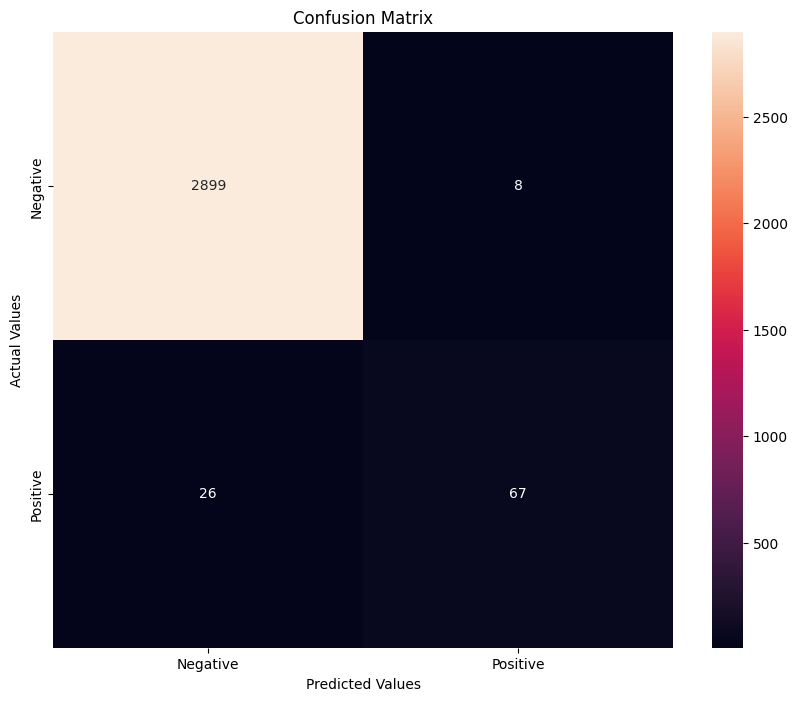

In [134]:
matrix = confusion_matrix(y_test, pred)
matrix = pd.DataFrame(matrix, index=['Negative', 'Positive'],
                              columns=['Negative', 'Positive'])
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

#### Prediction Threshold

I've never tried changing prediction threshold for XGBoost, but I want to give it a shot.

In [176]:
bestThresh = getBestThreshold(xg, X_test, y_test, resultsDict2, "XGBoost")
bestThresh

{'Precision': (1.0, 0.99),
 'Recall': (0.7526881720430108, 0.39),
 'F1 Score': (0.8045977011494253, 0.39),
 'Accuracy': (0.989, 0.53)}

I suppose I'm not actually that surprised that this worked, but it did, rather well, in fact.

In [178]:
baseProb = xg.predict_proba(X_test)[:, 1]
threshold = 0.39
customPred = (baseProb >= threshold).astype(int)

threshResults = saveTestResults(xg, customPred, y_test, resultsDict2, "XGBoost Threshold", isTrain=False)
threshResults

,Precision,Recall,F1 Score,Accuracy
0,0.864198,0.752688,0.804598,0.988667


### **Support Vector Machines**

In [170]:
def get_weightsSVM(model):
    '''Scores various combinations of class weights and outputs the results, 
    along with the strongest pair'''
    custom_weights = {0: 0.1, 1: 2}
    
    best_weights = {0: 0.1, 1: 2}
    best_score = 0
    
    results = {
    'Model': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Accuracy': []
    }
    for i in range(20):
        model.set_params(class_weight=custom_weights)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if len(results['F1 Score']) >= 2:
            try:
                if results['F1 Score'][-2] > results['F1 Score'][-1]:
                    best_weights[0] = float(results['Model'][-2].split(':')[0])
                    best_weights[1] = float(results['Model'][-2].split(':')[1])
                    best_score = results['F1 Score'][-2]
                    break
            except IndexError as e:
                print(e)
        
        custom_weights[0] = round(custom_weights[0] + 0.1, 1)
        custom_weights[1] = round(custom_weights[1] - 0.1, 1)

    while True:
        custom_weights[0] = round(custom_weights[0] + 0.1, 1)
        model.set_params(class_weight=custom_weights)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if best_score > results['F1 Score'][-1]:
            custom_weights[0] = best_weights[0]
            break
        elif best_score < results['F1 Score'][-1]:
            best_score = results['F1 Score'][-1]
            best_weights[0] = custom_weights[0]

    while True:
        custom_weights[0] = round(custom_weights[0] - 0.1, 1)
        model.set_params(class_weight=custom_weights)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if best_score > results['F1 Score'][-1]:
            custom_weights[0] = best_weights[0]
            break
        elif best_score < results['F1 Score'][-1]:
            best_score = results['F1 Score'][-1]
            best_weights[0] = custom_weights[0]

    while True:
        custom_weights[1] = round(custom_weights[1] + 0.1, 1)
        model.set_params(class_weight=custom_weights)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if best_score > results['F1 Score'][-1]:
            custom_weights[1] = best_weights[1]
            break
        elif best_score < results['F1 Score'][-1]:
            best_score = results['F1 Score'][-1]
            best_weights[1] = custom_weights[1]

    while True:
        custom_weights[1] = round(custom_weights[1] - 0.1, 1)
        model.set_params(class_weight=custom_weights)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        res = saveTestResults(model, pred, y_test, results, f"{custom_weights[0]}:{custom_weights[1]}", isTrain=False)

        if best_score > results['F1 Score'][-1]:
            custom_weights[1] = best_weights[1]
            break
        elif best_score < results['F1 Score'][-1]:
            best_score = results['F1 Score'][-1]
            best_weights[1] = custom_weights[1]
    
    return results

In [136]:
def scaledGamma(kernel, target, data):
    '''Function to compute relative optimal gamma value for SVM'''
    
    gammaVar = 0.0001
    decimals = 4
    
    results = {
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Accuracy': []
    }
    
    while True:
        if kernel == "poly":
            svm_classifier = SVC(kernel=kernel, gamma=gammaVar, random_state=42, degree=3)
        else:
            svm_classifier = SVC(kernel=kernel, gamma=gammaVar, random_state=42)

        svm_classifier.fit(X_train_scaled, y_train)
        this_pred = svm_classifier.predict(X_test_scaled)
        
        res = saveTestResults(svm_classifier, this_pred, target, data, "SVC", isTrain=True)
        results['Precision'].append((res['Precision'][0], gammaVar))
        results['Recall'].append((res['Recall'][0], gammaVar))
        results['F1 Score'].append((res['F1 Score'][0], gammaVar))
        results['Accuracy'].append((res['Accuracy'][0], gammaVar))

        if gammaVar >= 1:
            break
        else:
            if decimals > 2:
                decimals = decimals - 1
            gammaVar = round(gammaVar * 10, decimals)
            continue

    for key, value in results.items():
        results[key] = max(value)
    
    return results

In [137]:
def getBestGamma(target, kernel, lowerBound, upperBound):
    '''Function to compute relative optimal gamma value for SVM'''
    
    gammaVar = lowerBound
    
    results = {
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Accuracy': []
    }
    
    while True:
        svm_classifier = SVC(kernel=kernel, gamma=gammaVar, random_state=42)

        svm_classifier.fit(X_train_scaled, y_train)
        this_pred = svm_classifier.predict(X_test_scaled)
        
        res = saveTestResults(svm_classifier, this_pred, target, resultsDict1, "SVC", isTrain=True)
        results['Precision'].append((res['Precision'][0], gammaVar))
        results['Recall'].append((res['Recall'][0], gammaVar))
        results['F1 Score'].append((res['F1 Score'][0], gammaVar))
        results['Accuracy'].append((res['Accuracy'][0], gammaVar))

        if gammaVar >= upperBound:
            break
        else:
            gammaVar = round(gammaVar + 0.1, 2)
            continue

    for key, value in results.items():
        results[key] = max(value)
    
    return results

In [138]:
def scaleReg(model, target, lowerBound, upperBound):
    '''Function to compute relative optimal C value for SVM'''
    
    cVar = lowerBound
    decimals = 4
    
    results = {
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Accuracy': []
    }
    
    while True:
        model.set_params(C=cVar)

        model.fit(X_train_scaled, y_train)
        this_pred = model.predict(X_test_scaled)
        
        res = saveTestResults(model, this_pred, target, resultsDict1, "SVC", isTrain=True)
        results['Precision'].append((res['Precision'][0], cVar))
        results['Recall'].append((res['Recall'][0], cVar))
        results['F1 Score'].append((res['F1 Score'][0], cVar))
        results['Accuracy'].append((res['Accuracy'][0], cVar))

        if cVar >= upperBound:
            break
        else:
            if decimals > 2:
                decimals = decimals - 1
            cVar = round(cVar * 10, decimals)
            continue

    for key, value in results.items():
        results[key] = max(value)
    
    return results

In [139]:
def getBestReg(model, target, lowerBound, upperBound):
    '''Function to compute relative optimal C value for SVM'''
    
    cVar = lowerBound
    
    results = {
        'Precision': [],
        'Recall': [],
        'F1 Score': [],
        'Accuracy': []
    }
    
    while True:
        model.set_params(C=cVar)

        model.fit(X_train_scaled, y_train)
        this_pred = model.predict(X_test_scaled)
        
        res = saveTestResults(model, this_pred, target, resultsDict1, "SVC", isTrain=True)
        results['Precision'].append((res['Precision'][0], cVar))
        results['Recall'].append((res['Recall'][0], cVar))
        results['F1 Score'].append((res['F1 Score'][0], cVar))
        results['Accuracy'].append((res['Accuracy'][0], cVar))

        if cVar >= upperBound:
            break
        else:
            cVar = round(cVar + lowerBound, 4)
            continue

    for key, value in results.items():
        results[key] = max(value)
    
    return results

In [140]:
X = df2.drop(['Target'], axis=1)
y = df2['Target']
y = y.astype(bool)

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [142]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scaler = StandardScaler()
# SVM needs scaled data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [164]:
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)

pred = svm.predict(X_test_scaled)

In [165]:
svmResults = saveTestResults(svm, pred, y_test, resultsDict2, "SVM Vanilla", isTrain=False)
svmResults

,Precision,Recall,F1 Score,Accuracy
0,0.92,0.247312,0.389831,0.976


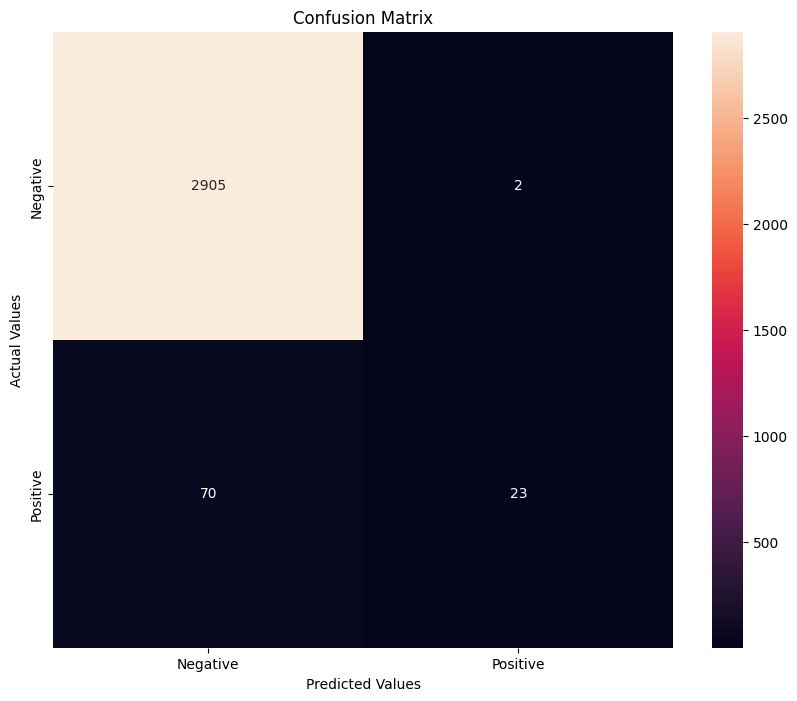

In [166]:
matrix = confusion_matrix(y_test, pred)
matrix = pd.DataFrame(matrix, index=['Negative', 'Positive'],
                              columns=['Negative', 'Positive'])
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

#### Gamma

In [145]:
bestGamma = scaledGamma('rbf', y_test, resultsDict2)
bestGamma

{'Precision': (0.9259259259259259, 1.0),
 'Recall': (0.26881720430107525, 1.0),
 'F1 Score': (0.4166666666666667, 1.0),
 'Accuracy': (0.9766666666666667, 1.0)}

Clearly, based on this, the best gamma is 1.0

#### Kernel

In [146]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
kernResults = {
    "Kernel": [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Accuracy': []
}
# For each kernel, add the highest recorded score for each metric
# along with its coinciding gamma value
for kernel in kernels:
    this_output = scaledGamma(kernel, y_test, resultsDict2)
    kernResults['Kernel'].append(kernel)
    kernResults['Precision'].append(this_output['Precision'])
    kernResults['Recall'].append(this_output['Recall'])
    kernResults['F1 Score'].append(this_output['F1 Score'])
    kernResults['Accuracy'].append(this_output['Accuracy'])

In [147]:
kernResultsDF = pd.DataFrame(kernResults)
kernResultsDF

,Kernel,Precision,Recall,F1 Score,Accuracy
0,linear,"(0.0, 1.0)","(0.0, 1.0)","(0.0, 1.0)","(0.969, 1.0)"
1,rbf,"(0.9259259259259259, 1.0)","(0.26881720430107525, 1.0)","(0.4166666666666667, 1.0)","(0.9766666666666667, 1.0)"
2,poly,"(0.8974358974358975, 0.1)","(0.6129032258064516, 1.0)","(0.6589595375722543, 1.0)","(0.9803333333333333, 1.0)"
3,sigmoid,"(0.1322314049586777, 0.1)","(0.17204301075268819, 0.1)","(0.14953271028037382, 0.1)","(0.969, 0.01)"


Clearly using the polynomial kernel with a gamma of roughly 1 is optimal, so let's refine the gamma for that kernel, and see what happens.

In [148]:
bestGamma = getBestGamma(y_test, 'poly', 0.1, 1)
bestGamma

{'Precision': (0.8974358974358975, 0.1),
 'Recall': (0.6559139784946236, 0.6),
 'F1 Score': (0.7195121951219512, 0.4),
 'Accuracy': (0.9846666666666667, 0.4)}

Score is greatly improved with a gamma of 0.4.

#### Regularization

Sadly, because of the way regularization works, it likely won't be very impactful for this dataset, aside from just using a value of 1. This is primarily because the dataset is very unbalanced, and altering the regularization with a higher value leads to a more severe penalty on the model when it places an incorrect classification. Since the data is unbalanced, it already is rather strict with its classification, and increasing it even more is just going to make the complexity of the model's training scale to a point where I will be unable to run it at all.

(I know this to be true, because I've experienced it several times already with SVM)

#### Class Weights

**Balanced**

In [167]:
svmWeight = SVC(kernel='poly', gamma=0.4, random_state=42, class_weight='balanced')

svmWeight.fit(X_train_scaled, y_train)
pred = svmWeight.predict(X_test_scaled)

svmWeightResults = saveTestResults(svmWeight, pred, y_test, resultsDict2, "SVM Weighted Bal", isTrain=False)
svmWeightResults

,Precision,Recall,F1 Score,Accuracy
0,0.35545,0.806452,0.493421,0.948667


**Custom**

In [171]:
svmCustomWeight = get_weightsSVM(svmWeight)

In [172]:
svmCustomWeightDF = pd.DataFrame(svmCustomWeight)
svmCustomWeightDF

,Model,Precision,Recall,F1 Score,Accuracy
0,0.1:2,0.362791,0.838710,0.506494,0.949333
1,0.2:1.9,0.467532,0.774194,0.582996,0.965667
2,0.3:1.8,0.514706,0.752688,0.611354,0.970333
3,0.4:1.7,0.584746,0.741935,0.654028,0.975667
4,0.5:1.6,0.603604,0.720430,0.656863,0.976667
5,0.6:1.5,0.622642,0.709677,0.663317,0.977667
6,0.7:1.4,0.659794,0.688172,0.673684,0.979333
7,0.8:1.3,0.692308,0.677419,0.684783,0.980667
8,0.9:1.2,0.753086,0.655914,0.701149,0.982667
9,1.0:1.1,0.819444,0.634409,0.715152,0.984333


It seems like 1 and 0.9 are the best for SVM.

In [173]:
svmWeight.set_params(class_weight={0: 1.0, 1: 0.9})
svmWeight.fit(X_train_scaled, y_train)
pred = svmWeight.predict(X_test_scaled)

finalSVM = saveTestResults(svmWeight, pred, y_test, resultsDict2, "SVM Weighted Cus", isTrain=False)
finalSVM

,Precision,Recall,F1 Score,Accuracy
0,0.830986,0.634409,0.719512,0.984667


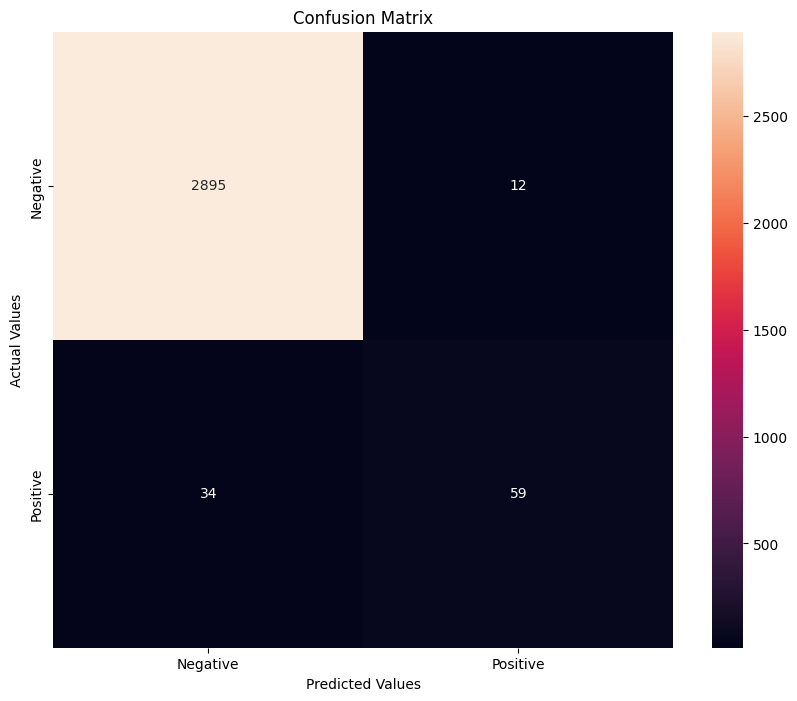

In [174]:
matrix = confusion_matrix(y_test, pred)
matrix = pd.DataFrame(matrix, index=['Negative', 'Positive'],
                              columns=['Negative', 'Positive'])
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

Overall, SVM can't really compete with random forest and XGBoost, for this dataset. I'm unsure if this is due to the fact that the dataset is heavily unbalanced, but that's my suspicion.

In [185]:
resultsDF = pd.DataFrame(resultsDict2)
resultsDF

,Model,Precision,Recall,F1 Score,Accuracy
0,RandomForest Vanilla2,0.904762,0.612903,0.730769,0.986000
1,RandomForest SMOTE2,0.484277,0.827957,0.611111,0.967333
2,RandomForest Threshold,0.865854,0.763441,0.811429,0.989000
3,RandomForest Pipeline2,0.720430,0.720430,0.720430,0.982667
4,XGBoost Vanilla,0.875000,0.677419,0.763636,0.987000
5,XGBoost Depth,0.888889,0.688172,0.775758,0.987667
6,XGBoost Learn,0.893333,0.720430,0.797619,0.988667
7,SVM Vanilla,0.920000,0.247312,0.389831,0.976000
8,SVM Weighted Bal,0.355450,0.806452,0.493421,0.948667
9,SVM Weighted Bal,0.355450,0.806452,0.493421,0.948667


## **Model Building - Iteration 3**

The only thing that will differ in this iteration is the use of resampling. While I could theoretically achieve perfect results using resampling, I won't do it to that extreme. I'll try to keep it realistic.

In [195]:
resultsDict3 = {
    'Model': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Accuracy': []
}

In [186]:
from sklearn.utils import resample

In [188]:
majority = df2[(df2['Target']) == 0]
minority = df2[(df2['Target']) == 1]

In [190]:
print(f'Majority: {len(majority)}')
print(f'Minority: {len(minority)}')

Majority: 9661
Minority: 339


In [202]:
min_resample = resample(minority, replace=True, n_samples=500, random_state=42)

In [203]:
upsample = pd.concat([min_resample, majority])

In [211]:
X = upsample.drop(['Target'], axis=1)
y = upsample['Target']
y = y.astype(bool)

In [212]:
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X, y, test_size=0.3, random_state=42)

### **Random Forest**

In [213]:
rfResample = RandomForestClassifier(random_state=42, n_jobs=-1)
rfResample.fit(X_train_res, y_train_res)
pred = rfResample.predict(X_test_res)

rfResampleResults = saveTestResults(rfResample, pred, y_test_res, resultsDict3, "RandomForest Resample", isTrain=False)
rfResampleResults

,Precision,Recall,F1 Score,Accuracy
0,0.96,0.852071,0.902821,0.989833


#### Test On Original Set

In [219]:
pred = rfResample.predict(X_test)

In [220]:
rfResampleOriginal = saveTestResults(rfResample, pred, y_test, resultsDict3, "RandomForest Resample", isTrain=False)
rfResampleOriginal

,Precision,Recall,F1 Score,Accuracy
0,0.974684,0.827957,0.895349,0.994


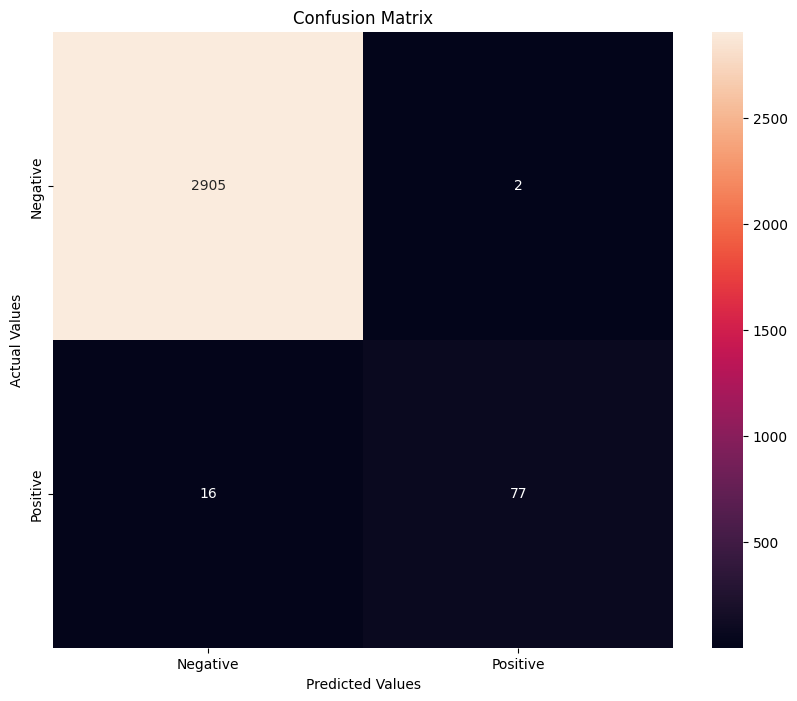

In [221]:
matrix = confusion_matrix(y_test, pred)
matrix = pd.DataFrame(matrix, index=['Negative', 'Positive'],
                              columns=['Negative', 'Positive'])
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

As shown by the results when compared to the original, pre-resampled test set, the newly trained model still performs significantly better than previous iterations. 

### **XGBoost**

In [217]:
xgResample = XGBClassifier(random_state=42)
xgResample.fit(X_train_res, y_train_res)
pred = xgResample.predict(X_test_res)

xgResampleResults = saveTestResults(xgResample, pred, y_test_res, resultsDict3, "XGBoost Resample", isTrain=False)
xgResampleResults

,Precision,Recall,F1 Score,Accuracy
0,0.929487,0.857988,0.892308,0.988521


#### Test On Original Set

In [222]:
pred = xgResample.predict(X_test)

xgResampleOriginal = saveTestResults(rfResample, pred, y_test, resultsDict3, "XGBoost Resample", isTrain=False)
xgResampleOriginal

,Precision,Recall,F1 Score,Accuracy
0,0.9875,0.849462,0.913295,0.995


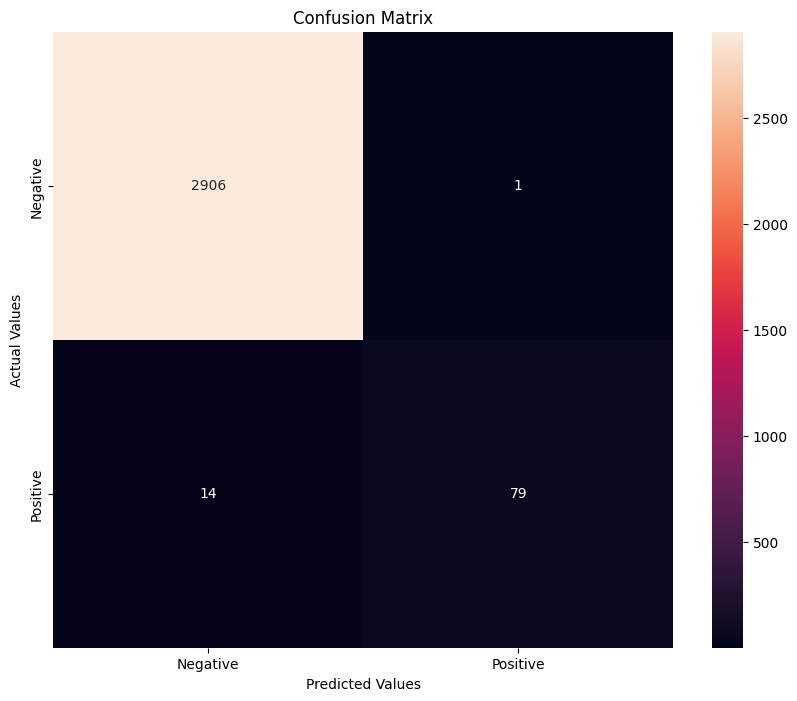

In [223]:
matrix = confusion_matrix(y_test, pred)
matrix = pd.DataFrame(matrix, index=['Negative', 'Positive'],
                              columns=['Negative', 'Positive'])
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

Interestingly, the XGBoost model actually performs even better on the original test set than it does on the resampled one. 

Still neither XGBoost, nor Random Forest make many predictions on true positives.

### **Final Results**

In [225]:
resultsDF1 = pd.DataFrame(resultsDict1)
resultsDF2 = pd.DataFrame(resultsDict2)
resultsDF3 = pd.DataFrame(resultsDict3)
dfs = [resultsDF1, resultsDF2, resultsDF3]

In [227]:
best_results = []
for df in dfs:
    sorted = df.sort_values(by='F1 Score', ascending=False)
    top_3 = sorted.head(3)
    best_results.append(top_3)

best_results = pd.concat(best_results, ignore_index=True)

In [228]:
best_results

,Model,Precision,Recall,F1 Score,Accuracy
0,RandomForest Threshold,0.875000,0.677419,0.763636,0.987000
1,RandomForest Vanilla,0.887097,0.591398,0.709677,0.985000
2,RandomForest Pipeline,0.650000,0.698925,0.673575,0.979000
3,RandomForest Threshold,0.865854,0.763441,0.811429,0.989000
4,XGBoost Threshold,0.864198,0.752688,0.804598,0.988667
5,XGBoost Learn,0.893333,0.720430,0.797619,0.988667
6,RandomForest Resample,0.957792,0.957792,0.957792,0.991885
7,RandomForest Resample,0.951691,0.912037,0.931442,0.990651
8,XGBoost Resample,0.987500,0.849462,0.913295,0.995000


## **Final Thoughts**

Originally, the models all struggled quite heavily with this dataset, mostly due to its relatively small size, and heavily unbalanced nature. However, with a decent amount of tweaking, all of the models were able to achieve a much higher performance, with the exception of SVM, which I had low expectations for in the first place.

The greatest jump in performance came from the use of resampling, which was not a surprise to me at all. However, unlike when I used this method previously, I kept the amount of resampling rather low, and only duplicated a third of the minority, rather than duplicating it in its entirety several times. Even with only a minor upscaling of this part of the data, the results for both Random Forest and XGBoost increased monumentally. 

Despite my measures to prevent fraudulent test results, I am still rather unconvinced, as I have to imagine that the models increase in performance was at least partially due to seeing duplicates of entries it saw in training. Nonetheless, I am satisfied with the results of the method, and will continue experimenting with it in the future.